# PROPEL Modeling Code 
PREDICTIVE ANALYTICS FOR MENTAL HEALTH: IDENTIFYING FACTORS INFLUENCING SUCCESSFUL TALK THERAPY OUTCOMES

In [1]:
## Load necessary packages
import pandas as pd 
import os
import numpy as np 
import seaborn as sns 
import platform
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,  StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, log_loss, classification_report
import shap
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from statsmodels.stats.contingency_tables import mcnemar
from scipy.stats import f_oneway, ttest_ind, chi2_contingency, ttest_rel
from sklearn.dummy import DummyClassifier
import statsmodels.formula.api as smf
from scipy import stats
from tabulate import tabulate

## Formating
import warnings
warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams.update({"font.size": 16})
alpha = 0.05
randomstate = 4


/opt/anaconda3/envs/machinelearning/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
## Read in clean dataset 
df = pd.read_csv ("df_encoded_models_NB.csv")
df.head()

,age,benefits,previous_mh,mh_other,mh_meds,physical_problems,gender,PHQ9_pre,GAD7_pre,WSAS_pre,...,impact_hyperarousal,rel_recovery,mh_onset_cat,ethnicity_3,condition_clean,current_mh_duration_clean,education_level_3,employment_status_3,self_compassion_pca,impact_pca
0,49.0,0,1,0,1,0,1,18.0,11.0,12.0,...,1.00,1.0,1,0,0,1,1,0,2.854200,-1.310648
1,33.0,0,1,1,0,0,1,19.0,8.0,15.0,...,5.96,1.0,1,0,0,1,0,0,1.556191,0.207050
2,70.0,0,0,0,1,1,1,7.0,12.0,9.0,...,4.00,1.0,1,0,0,1,1,2,1.917404,-2.500433
3,29.0,0,1,0,1,0,0,13.0,13.0,26.0,...,4.83,1.0,1,0,0,1,0,0,0.292061,-0.036095
4,58.0,0,1,0,1,1,1,13.0,12.0,21.0,...,4.00,1.0,1,0,1,0,0,0,1.901981,0.786107


## Train, validation, test split

In [3]:
## Split into train (70%), Validation (15%), and Test (15%)
## Use stratify by the outcome variable "rel_recovery"
train_df_1, rem_df_1 = train_test_split(df, train_size=0.7, stratify=df["rel_recovery"], random_state=randomstate)

val_df_1, test_df_1 = train_test_split(rem_df_1, train_size=0.5, stratify=rem_df_1["rel_recovery"], random_state=randomstate)


## Set Differences

### Continuous

In [4]:
continuous_features = ["age", "PHQ9_pre", "GAD7_pre", "WSAS_pre", "lonely_total_new", "self_compassion_pca", "resilience_total", "stresslife_total_new", 
            "perc_health_total", "loc_int", "loc_ext", "pers_extraversion", "pers_agreeable", "pers_conscientious", "pers_emotstab", "pers_openexp", 
            "cope_self_distract", "cope_active", "cope_denial", "cope_substuse", "cope_emotsupp", "cope_instrsupp", "cope_behavdisengage", "cope_venting", 
            "cope_posreframe", "cope_planning", "cope_humour", "cope_acceptance", "cope_religion", "cope_self_blame", "impact_pca"]

## ANOVA
for feature in continuous_features:
    groups = [train_df_1[feature], val_df_1[feature], test_df_1[feature]]
    result = f_oneway(*groups)
    
    group_num = len(groups)
    elements = sum(len(group) for group in groups)
    between_dof = group_num - 1
    within_dof = elements - group_num
    F_stat = result.statistic
    p_value = result.pvalue

    if p_value < 0.001:
        p_str = "<0.001"
    else:
        p_str = f"={p_value:.3f}"
    
    means = [group.mean() for group in groups]
    stdev = [group.std() for group in groups]
    stats_str = f"train={means[0]:.2f} ({stdev[0]:.2f}), val={means[1]:.2f} ({stdev[1]:.2f}), test={means[2]:.2f} ({stdev[2]:.2f})"
    print(f"{feature}: F({between_dof}, {within_dof})={F_stat:.2f} (p_value{p_str}) | means (SD): {stats_str}")

age: F(2, 870)=0.09 (p_value=0.910) | means (SD): train=43.34 (16.54), val=43.53 (16.85), test=44.04 (18.43)
PHQ9_pre: F(2, 870)=7.18 (p_value<0.001) | means (SD): train=16.31 (5.38), val=14.36 (5.73), test=15.78 (5.00)
GAD7_pre: F(2, 870)=5.22 (p_value=0.006) | means (SD): train=14.25 (4.71), val=12.85 (4.69), test=14.34 (4.11)
WSAS_pre: F(2, 870)=1.78 (p_value=0.170) | means (SD): train=20.43 (8.64), val=18.87 (8.38), test=20.11 (8.91)
lonely_total_new: F(2, 870)=0.44 (p_value=0.644) | means (SD): train=6.51 (1.87), val=6.56 (1.92), test=6.68 (1.96)
self_compassion_pca: F(2, 870)=1.00 (p_value=0.369) | means (SD): train=-0.02 (1.76), val=-0.09 (1.75), test=0.19 (1.84)
resilience_total: F(2, 870)=0.63 (p_value=0.533) | means (SD): train=28.64 (7.32), val=27.93 (7.55), test=28.87 (7.49)
stresslife_total_new: F(2, 870)=0.28 (p_value=0.757) | means (SD): train=6.38 (3.63), val=6.12 (3.53), test=6.33 (3.57)
perc_health_total: F(2, 870)=0.43 (p_value=0.649) | means (SD): train=8.67 (4.90),

### Categorical

In [5]:
categorical_features = ["benefits", "previous_mh", "mh_other", "mh_meds", "physical_problems", "gender", "rel_recovery", "mh_onset_cat",
                "ethnicity_3", "condition_clean", "current_mh_duration_clean", "education_level_3", "employment_status_3"]

## Chi-square
for feature in categorical_features:
    counts = pd.DataFrame({
        "train": train_df_1[feature].value_counts(),
        "val": val_df_1[feature].value_counts(),
        "test": test_df_1[feature].value_counts()})
    
    chi2, p, dof, expected = chi2_contingency(counts)
    
    if p_value < 0.001:
        p_str = "<0.001"
    else:
        p_str = f"={p_value:.3f}"
    
    print(f"\n{feature}: Chi2({dof})={chi2:.2f} (p_value{p_str})")
    print("Counts:\n", counts)


benefits: Chi2(2)=2.65 (p_value=0.137)
Counts:
           train  val  test
benefits                  
0           469  101    92
1           142   30    39

previous_mh: Chi2(2)=0.24 (p_value=0.137)
Counts:
              train  val  test
previous_mh                  
1              506  107   110
0              105   24    21

mh_other: Chi2(2)=4.89 (p_value=0.137)
Counts:
           train  val  test
mh_other                  
0           464  111   103
1           147   20    28

mh_meds: Chi2(2)=16.76 (p_value=0.137)
Counts:
          train  val  test
mh_meds                  
0          267   76    78
1          344   55    53

physical_problems: Chi2(2)=0.72 (p_value=0.137)
Counts:
                    train  val  test
physical_problems                  
0                    318   66    63
1                    293   65    68

gender: Chi2(4)=2.20 (p_value=0.137)
Counts:
         train  val  test
gender                  
1         445   89    99
0         160   41    31
2           

## One-hot encoding non-ordinal variables

In [6]:
## One-hot encode categorical variables
## Drop first to avoid multicollinearity
df_encoded = pd.get_dummies(df, columns=["gender", "mh_onset_cat", "ethnicity_3", "condition_clean", "employment_status_3"], drop_first=True)

train_df_encoded = pd.get_dummies(train_df_1, columns=["gender", "mh_onset_cat", "ethnicity_3", "condition_clean", "employment_status_3"], drop_first=True)

val_df_encoded = pd.get_dummies(val_df_1, columns=["gender", "mh_onset_cat", "ethnicity_3", "condition_clean", "employment_status_3"], drop_first=True)

test_df_encoded = pd.get_dummies(test_df_1, columns=["gender", "mh_onset_cat", "ethnicity_3", "condition_clean", "employment_status_3"], drop_first=True)


In [7]:
for idx, col_name in enumerate(df_encoded.columns):
    print(idx, col_name)

0 age
1 benefits
2 previous_mh
3 mh_other
4 mh_meds
5 physical_problems
6 PHQ9_pre
7 GAD7_pre
8 WSAS_pre
9 lonely_total_new
10 selfcomp_total
11 sc_recsuffer
12 sc_universality
13 sc_feeling
14 sc_tolerance
15 sc_action
16 resilience_total
17 stresslife_total_new
18 perc_health_total
19 loc_int
20 loc_ext
21 pers_extraversion
22 pers_agreeable
23 pers_conscientious
24 pers_emotstab
25 pers_openexp
26 cope_self_distract
27 cope_active
28 cope_denial
29 cope_substuse
30 cope_emotsupp
31 cope_instrsupp
32 cope_behavdisengage
33 cope_venting
34 cope_posreframe
35 cope_planning
36 cope_humour
37 cope_acceptance
38 cope_religion
39 cope_self_blame
40 impact_total
41 impact_intrusion
42 impact_avoidance
43 impact_hyperarousal
44 rel_recovery
45 current_mh_duration_clean
46 education_level_3
47 self_compassion_pca
48 impact_pca
49 gender_1
50 gender_2
51 mh_onset_cat_1
52 ethnicity_3_1
53 condition_clean_1
54 employment_status_3_1
55 employment_status_3_2


In [8]:
## Keep columns for modeling 
all_features = [0,1,2,3,4,5,6,7,8,9,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,
               45,46,47,48,49,50,51,52,53,54,55,44]

df_encoded_1 = df_encoded.iloc[:, all_features].copy()
train_df_encoded_1 = train_df_encoded.iloc[:, all_features].copy()
val_df_encoded_1 = val_df_encoded.iloc[:, all_features].copy()
test_df_encoded_1 = test_df_encoded.iloc[:, all_features].copy()

## Convert to numpy arrays
data = np.array(df_encoded_1)
train_df = np.array(train_df_encoded_1)
val_df = np.array(val_df_encoded_1)
test_df = np.array(test_df_encoded_1)

In [9]:
for idx, col_name in enumerate(test_df_encoded_1.columns):
    print(idx, col_name)

0 age
1 benefits
2 previous_mh
3 mh_other
4 mh_meds
5 physical_problems
6 PHQ9_pre
7 GAD7_pre
8 WSAS_pre
9 lonely_total_new
10 resilience_total
11 stresslife_total_new
12 perc_health_total
13 loc_int
14 loc_ext
15 pers_extraversion
16 pers_agreeable
17 pers_conscientious
18 pers_emotstab
19 pers_openexp
20 cope_self_distract
21 cope_active
22 cope_denial
23 cope_substuse
24 cope_emotsupp
25 cope_instrsupp
26 cope_behavdisengage
27 cope_venting
28 cope_posreframe
29 cope_planning
30 cope_humour
31 cope_acceptance
32 cope_religion
33 cope_self_blame
34 current_mh_duration_clean
35 education_level_3
36 self_compassion_pca
37 impact_pca
38 gender_1
39 gender_2
40 mh_onset_cat_1
41 ethnicity_3_1
42 condition_clean_1
43 employment_status_3_1
44 employment_status_3_2
45 rel_recovery


## Research Question
Which combination of sociodemographic, clinical, and psychosocial characteristics predict improvement of depression and anxiety among NHS TT users?

How accurately can these characteristics predict reliable improvement?

### Classification: reliable recovery or not 

#### Control analysis

In [10]:
## Outcome variable
rel_recovery = 45  

## Empty input
X_train_dummy = np.ones((train_df.shape[0], 1))
y_train_dummy = train_df[:, rel_recovery].astype(int)

X_test_dummy = np.ones((test_df.shape[0], 1))
y_test_dummy = test_df[:, rel_recovery].astype(int)

## Set sizes 
print(f"Train: {X_train_dummy.shape[0]}, Test: {X_test_dummy.shape[0]}")
print(f"Train: {X_train_dummy.shape[1]}, Test: {X_test_dummy.shape[1]}")

## Dummy Classifier 
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train_dummy, y_train_dummy)
dummy_pred = dummy_clf.predict(X_test_dummy)

## Results
print("Accuracy (Most Frequent):", accuracy_score(y_test_dummy, dummy_pred))
print("\nClassification Report (Most Frequent):")
print(classification_report(y_test_dummy, dummy_pred))
confusion = confusion_matrix(y_test_dummy, dummy_pred)
print (confusion)

results_dummy = {
    "Set": ["Test_Dummy_Full"],
    "Accuracy": [accuracy_score(y_test_dummy, dummy_pred)],
    "Precision": [precision_score(y_test_dummy, dummy_pred, average="binary")],  
    "Recall": [recall_score(y_test_dummy, dummy_pred, average="binary")],
    "F1 Score": [f1_score(y_test_dummy, dummy_pred, average="binary")],
    "ROC AUC": [roc_auc_score(y_test_dummy, dummy_pred)]}

results_df_dummy = pd.DataFrame(results_dummy)
print(results_df_dummy)

dummy_results = pd.DataFrame({
    "y_true_dummy": y_test_dummy,
    "y_pred_dummy": dummy_pred})

## Classification errors

dummy_results["Classifier_Correct_dummy"] = np.where(dummy_results["y_true_dummy"] == dummy_results["y_pred_dummy"], "yes", "no")

dummy_results.to_csv("dummy_classifier_test_predictions.csv", index=False)

Train: 611, Test: 131
Train: 1, Test: 1
Accuracy (Most Frequent): 0.5114503816793893

Classification Report (Most Frequent):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        64
           1       0.51      1.00      0.68        67

    accuracy                           0.51       131
   macro avg       0.26      0.50      0.34       131
weighted avg       0.26      0.51      0.35       131

[[ 0 64]
 [ 0 67]]
               Set  Accuracy  Precision  Recall  F1 Score  ROC AUC
0  Test_Dummy_Full   0.51145    0.51145     1.0  0.676768      0.5


#### Logistic Regression

In [11]:
## All Features
feat_col_full = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,
                34,35,36,37,38,39,40,41,42,43,44]

rel_recovery = 45
feature_names_LR1 = test_df_encoded_1.columns[feat_col_full]

X_train_LR1 = train_df[:, feat_col_full]
y_train_LR1 = train_df[:, rel_recovery].astype(int)

X_val_LR1 = val_df[:, feat_col_full]
y_val_LR1 = val_df[:, rel_recovery].astype(int)

X_test_LR1 = test_df[:, feat_col_full]
y_test_LR1 = test_df[:, rel_recovery].astype(int)

## Set sizes and variable numbers
print(f"Train: {X_train_LR1.shape[0]}, Val: {X_val_LR1.shape[0]}, Test: {X_test_LR1.shape[0]}")
print(f"Train: {X_train_LR1.shape[1]}, Val: {X_val_LR1.shape[1]}, Test: {X_test_LR1.shape[1]}")


Train: 611, Val: 131, Test: 131
Train: 45, Val: 45, Test: 45


In [12]:
## Scale Features
scaler = StandardScaler()

## Fit on training data set only
scaler.fit(X_train_LR1)

## Apply to all sets
X_train_scaled_LR1 = scaler.transform(X_train_LR1)
X_val_scaled_LR1 = scaler.transform(X_val_LR1)
X_test_scaled_LR1 = scaler.transform(X_test_LR1)

## Gridsearch
param_grid_LR1 = {
    "C": [0.01, 0.1, 1],
    "penalty": ["l1", "l2"],
    "class_weight": [None, "balanced"]}

base_model_LR1 = LogisticRegression(random_state=randomstate)
grid_search_LR1 = GridSearchCV(base_model_LR1, param_grid_LR1, cv=5, scoring="roc_auc", n_jobs=-1)
grid_search_LR1.fit(X_train_scaled_LR1, y_train_LR1)

## Optimal parameters
best_params_LR1 = grid_search_LR1.best_params_
print(f"\nBest Params: {best_params_LR1}")

## 10-Fold CV, randomise data before splitting by shuffling
skf_LR1 = StratifiedKFold(n_splits=10, shuffle=True, random_state=randomstate)

f1_scores_LR1 = []
rocauc_scores_LR1 = []
logloss_scores_LR1 = []
coefs_LR1 = []
all_test_sets_LR1 = []
all_preds_LR1 = []
all_true_LR1 = []
all_probs_LR1 = []

for fold, (train_idx_LR1, test_idx_LR1) in enumerate(skf_LR1.split(X_train_LR1, y_train_LR1), 1):
    X_fold_train_LR1, X_fold_test_LR1 = X_train_LR1[train_idx_LR1], X_train_LR1[test_idx_LR1]
    y_fold_train_LR1, y_fold_test_LR1 = y_train_LR1[train_idx_LR1], y_train_LR1[test_idx_LR1]

    ## Scale inside loop and use optimal parameters
    scaler_LR1 = StandardScaler()
    X_fold_train_scaled_LR1 = scaler_LR1.fit_transform(X_fold_train_LR1)
    X_fold_test_scaled_LR1 = scaler_LR1.transform(X_fold_test_LR1)

    model_LR1 = LogisticRegression(**best_params_LR1, random_state=randomstate)
    model_LR1.fit(X_fold_train_scaled_LR1, y_fold_train_LR1)

    y_pred_LR1 = model_LR1.predict(X_fold_test_scaled_LR1)
    y_prob_LR1 = model_LR1.predict_proba(X_fold_test_scaled_LR1)[:, 1]

    f1_LR1 = f1_score(y_fold_test_LR1, y_pred_LR1)
    rocauc_LR1 = roc_auc_score(y_fold_test_LR1, y_prob_LR1)
    logloss_LR1 = log_loss(y_fold_test_LR1, y_prob_LR1)

    f1_scores_LR1.append(f1_LR1)
    rocauc_scores_LR1.append(rocauc_LR1)
    logloss_scores_LR1.append(logloss_LR1)

    coefs_LR1.append(model_LR1.coef_[0])
    all_preds_LR1.extend(y_pred_LR1)
    all_true_LR1.extend(y_fold_test_LR1)
    all_probs_LR1.extend(y_prob_LR1)

## Final average scores
print(f"\nAverage CV F1 Score: {np.mean(f1_scores_LR1):.4f}")
print(f"Average CV ROC AUC: {np.mean(rocauc_scores_LR1):.4f}")
print(f"Average CV Log Loss: {np.mean(logloss_scores_LR1):.4f}")
print("Overall Precision:", precision_score(all_true_LR1, all_preds_LR1))
print("Overall Recall:", recall_score(all_true_LR1, all_preds_LR1))
print("Overall Log Loss:", log_loss(all_true_LR1, all_probs_LR1))

## Model Training on full scaled train set 
final_model_LR1 = LogisticRegression(**best_params_LR1, random_state=randomstate)
final_model_LR1.fit(X_train_scaled_LR1, y_train_LR1)

## Validation Set
y_val_pred_LR1 = final_model_LR1.predict(X_val_scaled_LR1)
y_val_proba_LR1 = final_model_LR1.predict_proba(X_val_scaled_LR1)[:, 1]

val_acc_LR1 = accuracy_score(y_val_LR1, y_val_pred_LR1)
val_prec_LR1 = precision_score(y_val_LR1, y_val_pred_LR1)
val_rec_LR1 = recall_score(y_val_LR1, y_val_pred_LR1)
val_f1_LR1 = f1_score(y_val_LR1, y_val_pred_LR1)
val_roc_auc_LR1 = roc_auc_score(y_val_LR1, y_val_proba_LR1)
val_confmat_LR1 = confusion_matrix(y_val_LR1, y_val_pred_LR1)
val_logloss_LR1 = log_loss(y_val_LR1, y_val_proba_LR1)

print("\nValidation Metrics:")
print(f"Accuracy: {val_acc_LR1:.4f}")
print(f"Precision: {val_prec_LR1:.4f}")
print(f"Recall: {val_rec_LR1:.4f}")
print(f"F1 Score: {val_f1_LR1:.4f}")
print(f"ROC AUC: {val_roc_auc_LR1:.4f}")
print(f"Log Loss: {val_logloss_LR1:.4f}")
print("Confusion Matrix:\n", val_confmat_LR1)
print("\nClassification Report:\n", classification_report(y_val_LR1, y_val_pred_LR1))

## Evaluation on Test Set
y_test_pred_LR1 = final_model_LR1.predict(X_test_scaled_LR1)
y_test_proba1_LR1 = final_model_LR1.predict_proba(X_test_scaled_LR1)[:, 1]

test_acc_LR1 = accuracy_score(y_test_LR1, y_test_pred_LR1)
test_prec_LR1 = precision_score(y_test_LR1, y_test_pred_LR1)
test_rec_LR1 = recall_score(y_test_LR1, y_test_pred_LR1)
test_f1_LR1 = f1_score(y_test_LR1, y_test_pred_LR1)
test_roc_auc_LR1 = roc_auc_score(y_test_LR1, y_test_proba1_LR1)
test_logloss_LR1 = log_loss(y_test_LR1, y_test_proba1_LR1)
test_confmat_LR1 = confusion_matrix(y_test_LR1, y_test_pred_LR1)

print("\nTest Metrics:")
print(f"Accuracy: {test_acc_LR1:.4f}")
print(f"Precision: {test_prec_LR1:.4f}")
print(f"Recall: {test_rec_LR1:.4f}")
print(f"F1 Score: {test_f1_LR1:.4f}")
print(f"ROC AUC: {test_roc_auc_LR1:.4f}")
print(f"Log Loss: {test_logloss_LR1:.4f}")
print("Confusion Matrix:\n", test_confmat_LR1)
print("\nClassification Report:\n", classification_report(y_test_LR1, y_test_pred_LR1))

## Collect metrics
results_LR1 = {
    "Set": ["Validation_LR", "Test_LR"],
    "Accuracy":   [val_acc_LR1, test_acc_LR1],
    "Precision":  [val_prec_LR1, test_prec_LR1],
    "Recall":     [val_rec_LR1, test_rec_LR1],
    "F1 Score":   [val_f1_LR1, test_f1_LR1],
    "ROC AUC":    [val_roc_auc_LR1, test_roc_auc_LR1],
    "Log Loss":   [val_logloss_LR1, test_logloss_LR1]}

## Save validation and test metrics and test set predictions/true values
results_df_LR = pd.DataFrame(results_LR1)
print(results_df_LR)

df_results_LR = pd.DataFrame({
    "y_true_LR": y_test_LR1,
    "y_pred_LR": y_test_pred_LR1})

df_results_LR["Classifier_Correct_lr"] = np.where(df_results_LR["y_true_LR"] == df_results_LR["y_pred_LR"], "yes", "no")

df_results_LR.to_csv ("LR_test_fullmodel_predictions.csv", index=False)



Best Params: {'C': 0.01, 'class_weight': None, 'penalty': 'l2'}

Average CV F1 Score: 0.6592
Average CV ROC AUC: 0.6929
Average CV Log Loss: 0.6373
Overall Precision: 0.6426426426426426
Overall Recall: 0.6793650793650794
Overall Log Loss: 0.6373791386333608

Validation Metrics:
Accuracy: 0.6183
Precision: 0.6184
Recall: 0.6912
F1 Score: 0.6528
ROC AUC: 0.6695
Log Loss: 0.6504
Confusion Matrix:
 [[34 29]
 [21 47]]

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.54      0.58        63
           1       0.62      0.69      0.65        68

    accuracy                           0.62       131
   macro avg       0.62      0.62      0.61       131
weighted avg       0.62      0.62      0.62       131


Test Metrics:
Accuracy: 0.6336
Precision: 0.6377
Recall: 0.6567
F1 Score: 0.6471
ROC AUC: 0.7192
Log Loss: 0.6144
Confusion Matrix:
 [[39 25]
 [23 44]]

Classification Report:
               precision    recall  f1-score   suppor

#### Random Forest

In [13]:
## All Features
feature_names_RF1 = test_df_encoded_1.columns[feat_col_full]

X_train_RF1 = train_df[:, feat_col_full]
y_train_RF1 = train_df[:, rel_recovery].astype(int)

X_val_RF1 = val_df[:, feat_col_full]
y_val_RF1 = val_df[:, rel_recovery].astype(int)

X_test_RF1 = test_df[:, feat_col_full]
y_test_RF1 = test_df[:, rel_recovery].astype(int)

print(f"Train: {X_train_RF1.shape[0]}, Val: {X_val_RF1.shape[0]}, Test: {X_test_RF1.shape[0]}")
print(f"Train: {X_train_RF1.shape[1]}, Val: {X_val_RF1.shape[1]}, Test: {X_test_RF1.shape[1]}")


Train: 611, Val: 131, Test: 131
Train: 45, Val: 45, Test: 45


In [14]:
## Scale Features
scaler_RF1 = StandardScaler()

## Fit on training data set only
scaler_RF1.fit(X_train_RF1)

## Apply to all sets
X_train_scaled_RF1 = scaler_RF1.transform(X_train_RF1)
X_val_scaled_RF1 = scaler_RF1.transform(X_val_RF1)
X_test_scaled_RF1 = scaler_RF1.transform(X_test_RF1)

## GridSearch
param_grid_RF1 = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 15, 20],
    "class_weight": [None, "balanced"]}

rf_RF1 = RandomForestClassifier(random_state=randomstate)
grid_search_RF1 = GridSearchCV(rf_RF1, param_grid_RF1, cv=5, scoring="roc_auc", n_jobs=-1)
grid_search_RF1.fit(X_train_scaled_RF1, y_train_RF1)

## Optimal hyperparameters
best_params_RF1 = grid_search_RF1.best_params_
print(f"\nBest Params: {best_params_RF1}")

## Cross validation
skf_RF1 = StratifiedKFold(n_splits=10, shuffle=True, random_state=randomstate)

f1_scores_RF1 = []
rocauc_scores_RF1 = []
all_preds_RF1 = []
all_true_RF1 = []
logloss_scores_RF1 = []

for fold, (train_idx_RF1, test_idx_RF1) in enumerate(skf_RF1.split(X_train_RF1, y_train_RF1), 1):
    X_fold_train_raw_RF1, X_fold_test_raw_RF1 = X_train_RF1[train_idx_RF1], X_train_RF1[test_idx_RF1]
    y_fold_train_RF1, y_fold_test_RF1 = y_train_RF1[train_idx_RF1], y_train_RF1[test_idx_RF1]
    scaler_fold_RF1 = StandardScaler()
    scaler_fold_RF1.fit(X_fold_train_raw_RF1)
    X_fold_train_RF1 = scaler_fold_RF1.transform(X_fold_train_raw_RF1)
    X_fold_test_RF1 = scaler_fold_RF1.transform(X_fold_test_raw_RF1)

    model_RF1 = RandomForestClassifier(**best_params_RF1, random_state=randomstate)
    model_RF1.fit(X_fold_train_RF1, y_fold_train_RF1)

    y_pred_RF1 = model_RF1.predict(X_fold_test_RF1)
    y_prob_RF1 = model_RF1.predict_proba(X_fold_test_RF1)[:, 1]

    f1_RF1 = f1_score(y_fold_test_RF1, y_pred_RF1)
    f1_scores_RF1.append(f1_RF1)

    rocauc_RF1 = roc_auc_score(y_fold_test_RF1, y_prob_RF1)
    rocauc_scores_RF1.append(rocauc_RF1)

    logloss_RF1 = log_loss(y_fold_test_RF1, y_prob_RF1)
    logloss_scores_RF1.append(logloss_RF1)

    all_preds_RF1.extend(y_pred_RF1)
    all_true_RF1.extend(y_fold_test_RF1)

    print(f"Fold {fold} F1 Score: {f1_RF1:.4f}, ROC AUC: {rocauc_RF1:.4f}, Log Loss: {logloss_RF1:.4f}")

print(f"\nAverage CV F1 Score: {np.mean(f1_scores_RF1):.4f}")
print(f"Average CV ROC AUC: {np.mean(rocauc_scores_RF1):.4f}")
print(f"Average CV Log Loss: {np.mean(logloss_scores_RF1):.4f}")
print("Overall Precision:", precision_score(all_true_RF1, all_preds_RF1))
print("Overall Recall:", recall_score(all_true_RF1, all_preds_RF1))

## Train model on full scaled train set
final_model_RF1 = RandomForestClassifier(**best_params_RF1, random_state=randomstate)
final_model_RF1.fit(X_train_scaled_RF1, y_train_RF1)

## Validation set
y_val_pred_RF1 = final_model_RF1.predict(X_val_scaled_RF1)
y_val_proba_RF1 = final_model_RF1.predict_proba(X_val_scaled_RF1)[:, 1]

val_acc_RF1 = accuracy_score(y_val_RF1, y_val_pred_RF1)
val_prec_RF1 = precision_score(y_val_RF1, y_val_pred_RF1)
val_rec_RF1 = recall_score(y_val_RF1, y_val_pred_RF1)
val_f1_RF1 = f1_score(y_val_RF1, y_val_pred_RF1)
val_roc_auc_RF1 = roc_auc_score(y_val_RF1, y_val_proba_RF1)
val_confmat_RF1 = confusion_matrix(y_val_RF1, y_val_pred_RF1)
val_logloss_RF1 = log_loss(y_val_RF1, y_val_proba_RF1)

print("\nValidation Metrics:")
print(f"Accuracy:     {val_acc_RF1:.4f}")
print(f"Precision:    {val_prec_RF1:.4f}")
print(f"Recall:       {val_rec_RF1:.4f}")
print(f"F1 Score:     {val_f1_RF1:.4f}")
print(f"ROC AUC:      {val_roc_auc_RF1:.4f}")
print(f"Log Loss:     {val_logloss_RF1:.4f}")
print("Confusion Matrix:\n", val_confmat_RF1)
print("\nClassification Report:\n", classification_report(y_val_RF1, y_val_pred_RF1))

## Evaluate on Test set
y_test_pred_RF1 = final_model_RF1.predict(X_test_scaled_RF1)
y_test_proba3_RF1 = final_model_RF1.predict_proba(X_test_scaled_RF1)[:, 1]

test_acc_RF1 = accuracy_score(y_test_RF1, y_test_pred_RF1)
test_prec_RF1 = precision_score(y_test_RF1, y_test_pred_RF1)
test_rec_RF1 = recall_score(y_test_RF1, y_test_pred_RF1)
test_f1_RF1 = f1_score(y_test_RF1, y_test_pred_RF1)
test_roc_auc_RF1 = roc_auc_score(y_test_RF1, y_test_proba3_RF1)
test_confmat_RF1 = confusion_matrix(y_test_RF1, y_test_pred_RF1)
test_logloss_RF1 = log_loss(y_test_RF1, y_test_proba3_RF1)

print("\nTest Metrics:")
print(f"Accuracy:     {test_acc_RF1:.4f}")
print(f"Precision:    {test_prec_RF1:.4f}")
print(f"Recall:       {test_rec_RF1:.4f}")
print(f"F1 Score:     {test_f1_RF1:.4f}")
print(f"ROC AUC:      {test_roc_auc_RF1:.4f}")
print(f"Log Loss:     {test_logloss_RF1:.4f}")
print("Confusion Matrix:\n", test_confmat_RF1)
print("\nClassification Report:\n", classification_report(y_test_RF1, y_test_pred_RF1))

results_RF1 = {
    "Set": ["Validation_RF", "Test_RF"],
    "Accuracy": [val_acc_RF1, test_acc_RF1],
    "Precision": [val_prec_RF1, test_prec_RF1],
    "Recall": [val_rec_RF1, test_rec_RF1],
    "F1 Score": [val_f1_RF1, test_f1_RF1],
    "ROC AUC": [val_roc_auc_RF1, test_roc_auc_RF1],
    "Log Loss": [val_logloss_RF1, test_logloss_RF1]}

## Save validation and test metrics and test set predictions/true values
results_df_RF = pd.DataFrame(results_RF1)
print(results_df_RF)

df_results_RF = pd.DataFrame({
    "y_true_RF": y_test_RF1,
    "y_pred_RF": y_test_pred_RF1})

df_results_RF["Classifier_Correct_RF"] = np.where(df_results_RF["y_true_RF"] == df_results_RF["y_pred_RF"], "yes", "no")

df_results_RF.to_csv ("RF_test_fullmodel_predictions.csv", index=False)


Best Params: {'class_weight': None, 'max_depth': 10, 'n_estimators': 300}
Fold 1 F1 Score: 0.5455, ROC AUC: 0.6094, Log Loss: 0.6841
Fold 2 F1 Score: 0.7077, ROC AUC: 0.7624, Log Loss: 0.5982
Fold 3 F1 Score: 0.7419, ROC AUC: 0.7710, Log Loss: 0.5974
Fold 4 F1 Score: 0.6349, ROC AUC: 0.7011, Log Loss: 0.6306
Fold 5 F1 Score: 0.6462, ROC AUC: 0.7355, Log Loss: 0.5913
Fold 6 F1 Score: 0.6316, ROC AUC: 0.6290, Log Loss: 0.6787
Fold 7 F1 Score: 0.6866, ROC AUC: 0.6659, Log Loss: 0.6562
Fold 8 F1 Score: 0.5357, ROC AUC: 0.6444, Log Loss: 0.6672
Fold 9 F1 Score: 0.7077, ROC AUC: 0.7414, Log Loss: 0.6042
Fold 10 F1 Score: 0.6571, ROC AUC: 0.6616, Log Loss: 0.6576

Average CV F1 Score: 0.6495
Average CV ROC AUC: 0.6922
Average CV Log Loss: 0.6366
Overall Precision: 0.6448598130841121
Overall Recall: 0.6571428571428571

Validation Metrics:
Accuracy:     0.6641
Precision:    0.6579
Recall:       0.7353
F1 Score:     0.6944
ROC AUC:      0.6671
Log Loss:     0.6502
Confusion Matrix:
 [[37 26]
 [

#### XGBoost

In [15]:
feature_names_XG1 = test_df_encoded_1.columns[feat_col_full]

X_train_XG1 = train_df[:, feat_col_full]
y_train_XG1 = train_df[:, rel_recovery].astype(int)

X_val_XG1 = val_df[:, feat_col_full]
y_val_XG1 = val_df[:, rel_recovery].astype(int)

X_test_XG1 = test_df[:, feat_col_full]
y_test_XG1 = test_df[:, rel_recovery].astype(int)

print(f"Train: {X_train_XG1.shape[0]}, Val: {X_val_XG1.shape[0]}, Test: {X_test_XG1.shape[0]}")
print(f"Train: {X_train_XG1.shape[1]}, Val: {X_val_XG1.shape[1]}, Test: {X_test_XG1.shape[1]}")

Train: 611, Val: 131, Test: 131
Train: 45, Val: 45, Test: 45


In [16]:
## Scale Features
scaler_XG1 = StandardScaler()
X_train_scaled_XG1 = scaler_XG1.fit_transform(X_train_XG1)
X_val_scaled_XG1 = scaler_XG1.transform(X_val_XG1)
X_test_scaled_XG1 = scaler_XG1.transform(X_test_XG1)

## GridSearch
param_grid_XG1 = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7]}

base_model_XG1 = XGBClassifier(random_state=randomstate)
grid_search_XG1 = GridSearchCV(base_model_XG1, param_grid_XG1, cv=5, scoring="roc_auc", n_jobs=-1)
grid_search_XG1.fit(X_train_scaled_XG1, y_train_XG1)

## Optimal hyperparameteres
best_params_XG1 = grid_search_XG1.best_params_
print(f"\nBest Params: {best_params_XG1}")

## 10-Fold CV 
skf_XG1 = StratifiedKFold(n_splits=10, shuffle=True, random_state=randomstate)

f1_scores_XG1 = []
rocauc_scores_XG1 = []
logloss_scores_XG1 = []
all_preds_XG1 = []
all_true_XG1 = []

for fold, (train_idx_XG1, test_idx_XG1) in enumerate(skf_XG1.split(X_train_scaled_XG1, y_train_XG1), 1):
    X_fold_train_XG1 = X_train_scaled_XG1[train_idx_XG1]
    X_fold_test_XG1 = X_train_scaled_XG1[test_idx_XG1]
    y_fold_train_XG1 = y_train_XG1[train_idx_XG1]
    y_fold_test_XG1 = y_train_XG1[test_idx_XG1]

    model_XG1 = XGBClassifier(**best_params_XG1,random_state=randomstate,use_label_encoder=False)
    model_XG1.fit(X_fold_train_XG1, y_fold_train_XG1)

    y_pred_XG1 = model_XG1.predict(X_fold_test_XG1)
    y_proba_XG1 = model_XG1.predict_proba(X_fold_test_XG1)[:, 1]  

    f1_XG1 = f1_score(y_fold_test_XG1, y_pred_XG1)
    f1_scores_XG1.append(f1_XG1)

    rocauc_XG1 = roc_auc_score(y_fold_test_XG1, y_proba_XG1)
    rocauc_scores_XG1.append(rocauc_XG1)

    logloss_XG1 = log_loss(y_fold_test_XG1, y_proba_XG1)
    logloss_scores_XG1.append(logloss_XG1)

    all_preds_XG1.extend(y_pred_XG1)
    all_true_XG1.extend(y_fold_test_XG1)

    print(f"Fold {fold} F1 Score: {f1_XG1:.4f}, ROC AUC: {rocauc_XG1:.4f}, Log Loss: {logloss_XG1:.4f}")

print(f"\nAverage CV F1 Score: {np.mean(f1_scores_XG1):.4f}")
print(f"Average CV ROC AUC: {np.mean(rocauc_scores_XG1):.4f}")
print(f"Average CV Log Loss: {np.mean(logloss_scores_XG1):.4f}")
print("Overall Precision:", precision_score(all_true_XG1, all_preds_XG1))
print("Overall Recall:", recall_score(all_true_XG1, all_preds_XG1))

## Train model 
final_model_XG1 = XGBClassifier(**best_params_XG1, random_state=randomstate, use_label_encoder=False)
final_model_XG1.fit(X_train_scaled_XG1, y_train_XG1)


## Validation set
y_val_pred_XG1 = final_model_XG1.predict(X_val_scaled_XG1)
y_val_proba_XG1 = final_model_XG1.predict_proba(X_val_scaled_XG1)[:, 1]

val_roc_auc_XG1 = roc_auc_score(y_val_XG1, y_val_proba_XG1)
val_prec_XG1 = precision_score(y_val_XG1, y_val_pred_XG1)
val_rec_XG1 = recall_score(y_val_XG1, y_val_pred_XG1)
val_f1_XG1 = f1_score(y_val_XG1, y_val_pred_XG1)
val_acc_XG1 = accuracy_score(y_val_XG1, y_val_pred_XG1)
val_logloss_XG1 = log_loss(y_val_XG1, y_val_proba_XG1)
val_confmat_XG1 = confusion_matrix(y_val_XG1, y_val_pred_XG1)

print("\nValidation Metrics:")
print(f"Accuracy:     {val_acc_XG1:.4f}")
print(f"Precision:    {val_prec_XG1:.4f}")
print(f"Recall:       {val_rec_XG1:.4f}")
print(f"F1 Score:     {val_f1_XG1:.4f}")
print(f"ROC AUC:      {val_roc_auc_XG1:.4f}")
print(f"Log Loss:     {val_logloss_XG1:.4f}")
print("Confusion Matrix:\n", val_confmat_XG1)
print("\nClassification Report:\n", classification_report(y_val_XG1, y_val_pred_XG1))

## Evaluate on test set 
y_test_pred_XG1 = final_model_XG1.predict(X_test_scaled_XG1)
y_test_proba5_XG1 = final_model_XG1.predict_proba(X_test_scaled_XG1)[:, 1]

test_roc_auc_XG1 = roc_auc_score(y_test_XG1, y_test_proba5_XG1)
test_prec_XG1 = precision_score(y_test_XG1, y_test_pred_XG1)
test_rec_XG1 = recall_score(y_test_XG1, y_test_pred_XG1)
test_f1_XG1 = f1_score(y_test_XG1, y_test_pred_XG1)
test_acc_XG1 = accuracy_score(y_test_XG1, y_test_pred_XG1)
test_logloss_XG1 = log_loss(y_test_XG1, y_test_proba5_XG1)
test_confmat_XG1 = confusion_matrix(y_test_XG1, y_test_pred_XG1)

print("\nTest Metrics:")
print(f"Accuracy:     {test_acc_XG1:.4f}")
print(f"Precision:    {test_prec_XG1:.4f}")
print(f"Recall:       {test_rec_XG1:.4f}")
print(f"F1 Score:     {test_f1_XG1:.4f}")
print(f"ROC AUC:      {test_roc_auc_XG1:.4f}")
print(f"Log Loss:     {test_logloss_XG1:.4f}")
print("Confusion Matrix:\n", test_confmat_XG1)

results_XG1 = {
    "Set": ["Validation_XG", "Test_XG"],
    "Accuracy": [val_acc_XG1, test_acc_XG1],
    "Precision": [val_prec_XG1, test_prec_XG1],
    "Recall": [val_rec_XG1, test_rec_XG1],
    "F1 Score": [val_f1_XG1, test_f1_XG1],
    "ROC AUC": [val_roc_auc_XG1, test_roc_auc_XG1],
    "Log Loss": [val_logloss_XG1, test_logloss_XG1]}

## Save validation and test metrics and test set predictions/true values
results_df_XG = pd.DataFrame(results_XG1)
print(results_df_XG)

df_results_XG = pd.DataFrame({
    "y_true_xg": y_test_XG1,
    "y_pred_xg": y_test_pred_XG1})

df_results_XG["Classifier_Correct_xg"] = np.where(df_results_XG["y_true_xg"] == df_results_XG["y_pred_xg"], "yes", "no")

df_results_XG.to_csv ("XG_test_fullmodel_predictions.csv", index=False)


Best Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Fold 1 F1 Score: 0.6154, ROC AUC: 0.5938, Log Loss: 0.6886
Fold 2 F1 Score: 0.7778, ROC AUC: 0.8054, Log Loss: 0.5737
Fold 3 F1 Score: 0.7164, ROC AUC: 0.7495, Log Loss: 0.6036
Fold 4 F1 Score: 0.6769, ROC AUC: 0.6968, Log Loss: 0.6372
Fold 5 F1 Score: 0.6875, ROC AUC: 0.7194, Log Loss: 0.6133
Fold 6 F1 Score: 0.6230, ROC AUC: 0.6538, Log Loss: 0.6521
Fold 7 F1 Score: 0.6857, ROC AUC: 0.6875, Log Loss: 0.6579
Fold 8 F1 Score: 0.6102, ROC AUC: 0.6315, Log Loss: 0.6773
Fold 9 F1 Score: 0.6970, ROC AUC: 0.7446, Log Loss: 0.5959
Fold 10 F1 Score: 0.6761, ROC AUC: 0.6681, Log Loss: 0.6518

Average CV F1 Score: 0.6766
Average CV ROC AUC: 0.6950
Average CV Log Loss: 0.6351
Overall Precision: 0.6492753623188405
Overall Recall: 0.7111111111111111

Validation Metrics:
Accuracy:     0.6107
Precision:    0.6197
Recall:       0.6471
F1 Score:     0.6331
ROC AUC:      0.6629
Log Loss:     0.6540
Confusion Matrix:
 [[36 27]
 [

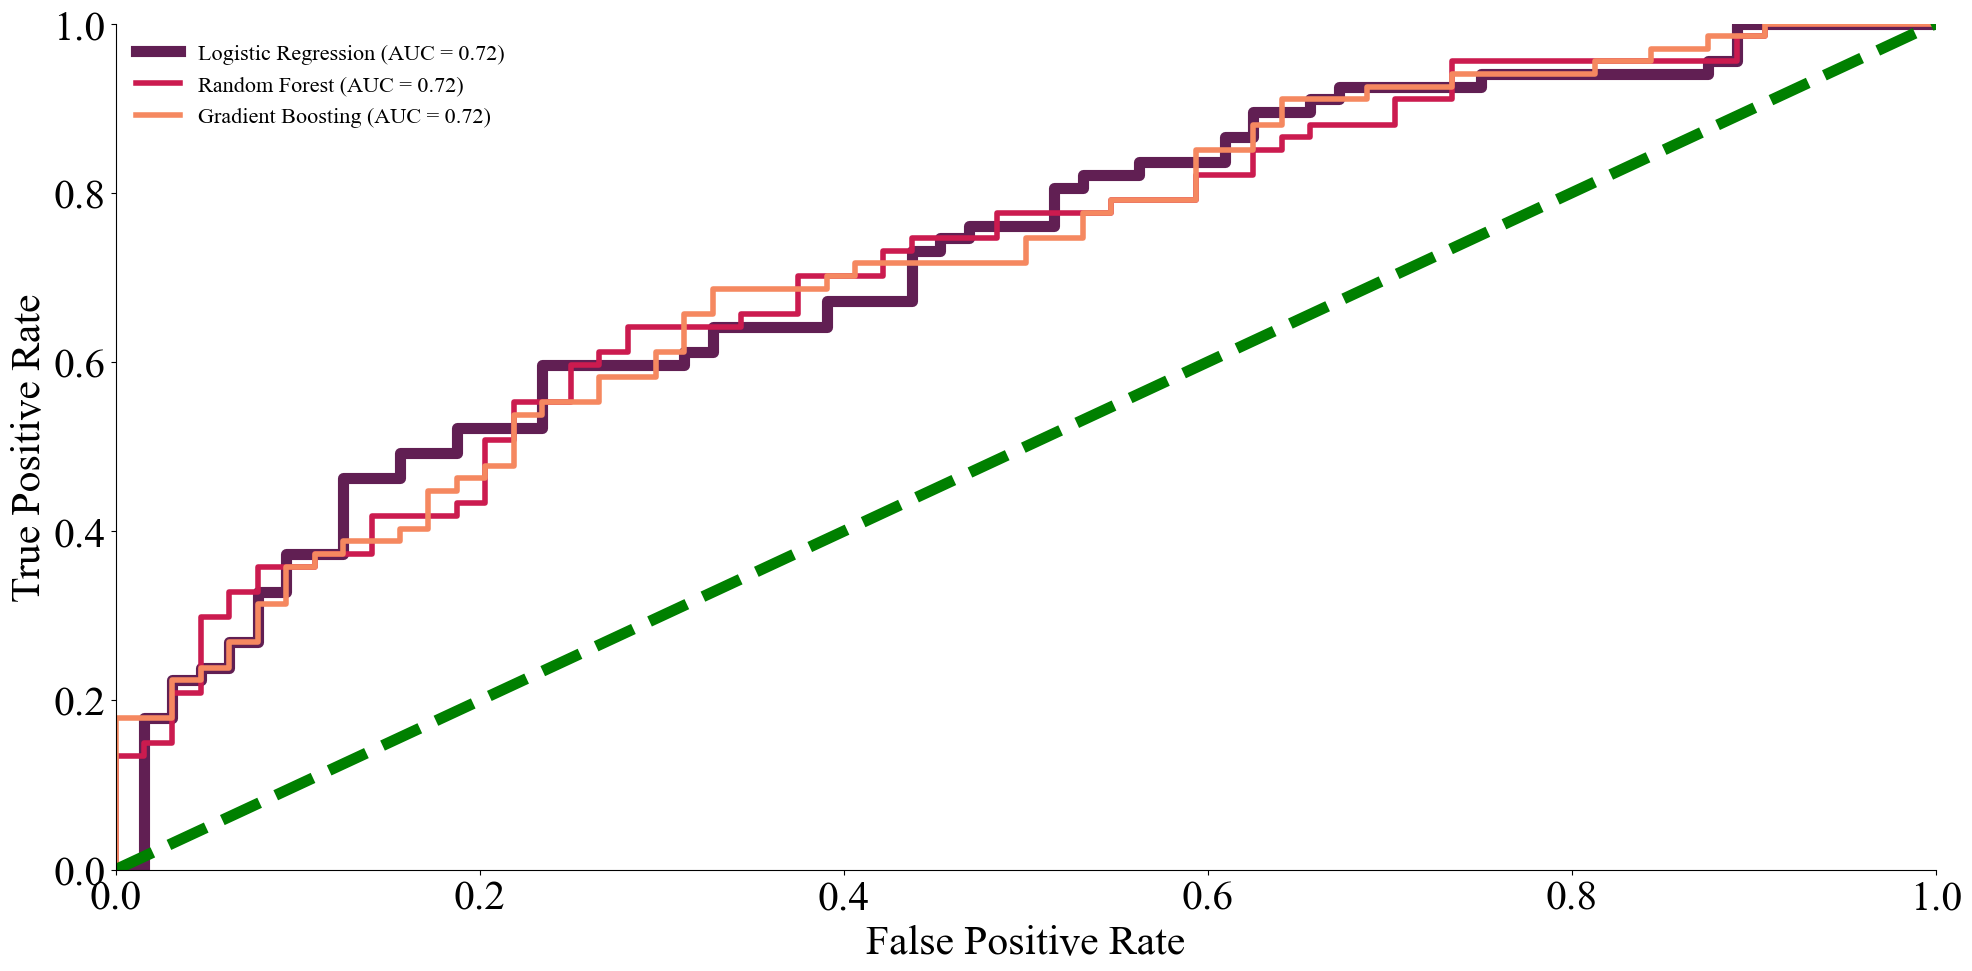

In [18]:
## Logistic regression
fpr_lr, tpr_lr, _ = roc_curve(y_test_LR1, y_test_proba1_LR1)
auc_lr = auc(fpr_lr, tpr_lr)

## Random forest
fpr_rf, tpr_rf, _ = roc_curve(y_test_RF1, y_test_proba3_RF1)
auc_rf = auc(fpr_rf, tpr_rf)

## XGBoost
fpr_gb, tpr_gb, _ = roc_curve(y_test_XG1, y_test_proba5_XG1)
auc_gb = auc(fpr_gb, tpr_gb)

fig, ax = plt.subplots(figsize=(20, 10))
cols = sns.color_palette("rocket", 3)
ax.plot(
    fpr_lr, tpr_lr,
    linewidth=8,
    color=cols[0],
    label=f"Logistic Regression (AUC = {auc_lr:.2f})"
)

ax.plot(
    fpr_rf, tpr_rf,
    linewidth=4,
    color=cols[1],
    label=f"Random Forest (AUC = {auc_rf:.2f})"
)

ax.plot(
    fpr_gb, tpr_gb,
    linewidth=4,
    color=cols[2],
    label=f"Gradient Boosting (AUC = {auc_gb:.2f})"
)

ax.plot(
    [0, 1], [0, 1],
    linestyle="--",
    linewidth=8,
    color="green"
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("False Positive Rate", fontsize=30)
ax.set_ylabel("True Positive Rate", fontsize=30)
ax.tick_params(axis="both", labelsize=30)

legend = ax.legend()

legend.get_frame().set_facecolor("none")
legend.get_frame().set_edgecolor("none")
legend.get_frame().set_alpha(0)
sns.despine(ax=ax)
ax.set_facecolor("none")
fig.patch.set_alpha(0)

plt.tight_layout()

plt.savefig(
    "ROC_3_transparent.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)
plt.show()


### Comparison of Classification Models

In [19]:
print (results_df_LR)
print (results_df_RF)
print (results_df_XG)
print (results_df_dummy)

             Set  Accuracy  Precision    Recall  F1 Score   ROC AUC  Log Loss
0  Validation_LR  0.618321   0.618421  0.691176  0.652778  0.669468  0.650441
1        Test_LR  0.633588   0.637681  0.656716  0.647059  0.719216  0.614373
             Set  Accuracy  Precision    Recall  F1 Score   ROC AUC  Log Loss
0  Validation_RF  0.664122   0.657895  0.735294  0.694444  0.667134  0.650231
1        Test_RF  0.648855   0.652174  0.671642  0.661765  0.716884  0.619034
             Set  Accuracy  Precision    Recall  F1 Score   ROC AUC  Log Loss
0  Validation_XG  0.610687   0.619718  0.647059  0.633094  0.662932  0.654006
1        Test_XG  0.664122   0.666667  0.686567  0.676471  0.715252  0.617496
               Set  Accuracy  Precision  Recall  F1 Score  ROC AUC
0  Test_Dummy_Full   0.51145    0.51145     1.0  0.676768      0.5


In [20]:
combined_df = pd.concat([
    results_df_LR,
    results_df_RF,
    results_df_XG
], ignore_index=True)
combined_df = combined_df.round(4)
print(combined_df)

combined_df.to_csv ("classification_metrics.csv", index=False)

             Set  Accuracy  Precision  Recall  F1 Score  ROC AUC  Log Loss
0  Validation_LR    0.6183     0.6184  0.6912    0.6528   0.6695    0.6504
1        Test_LR    0.6336     0.6377  0.6567    0.6471   0.7192    0.6144
2  Validation_RF    0.6641     0.6579  0.7353    0.6944   0.6671    0.6502
3        Test_RF    0.6489     0.6522  0.6716    0.6618   0.7169    0.6190
4  Validation_XG    0.6107     0.6197  0.6471    0.6331   0.6629    0.6540
5        Test_XG    0.6641     0.6667  0.6866    0.6765   0.7153    0.6175


#### Figures

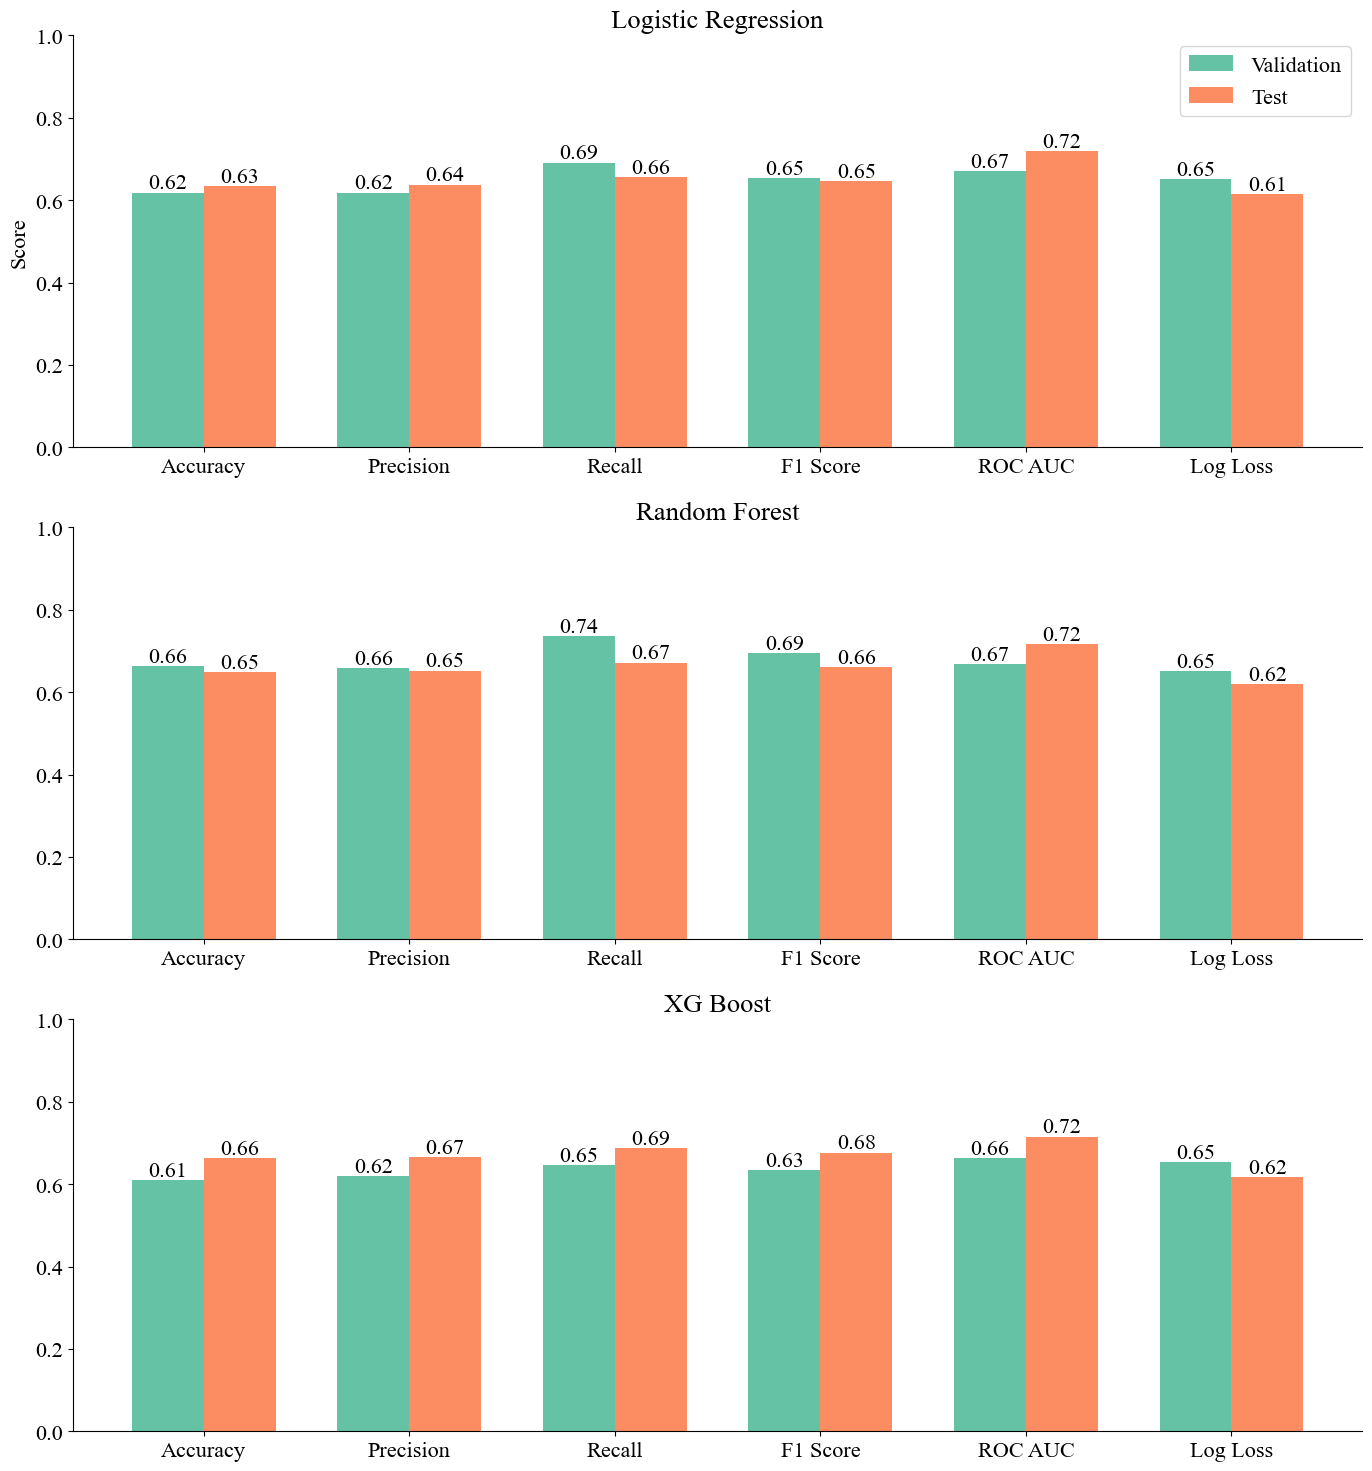

In [21]:
combined_df["Model"] = combined_df["Set"].str.extract(r"(LR|RF|XG)")
combined_df["Split"] = combined_df["Set"].str.extract(r"(Validation|Test)")

## Rename
model_names = {"LR": "Logistic Regression", "RF": "Random Forest", "XG": "XG Boost"}

metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC", "Log Loss"]
models = ["LR", "RF", "XG"]
palette = sns.color_palette("Set2", 2)
split_order = ["Validation", "Test"]

fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=False, sharey=True)

for ax, model in zip(axes, models):
    model_data = combined_df[combined_df["Model"] == model]
    val_scores = model_data[model_data["Split"] == "Validation"][metrics].values.flatten()
    test_scores = model_data[model_data["Split"] == "Test"][metrics].values.flatten()
    x = range(len(metrics))
    width = 0.35
    ax.bar([i - width/2 for i in x], val_scores, width, label="Validation", color=palette[0])
    ax.bar([i + width/2 for i in x], test_scores, width, label="Test", color=palette[1])

    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=0, ha="center")
    ax.set_title(model_names[model])
    ax.set_ylim(0, 1)
    for i, v in enumerate(val_scores):
        ax.text(i - width/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=16)
    for i, v in enumerate(test_scores):
        ax.text(i + width/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=16)
    if ax == axes[0]:
        ax.set_ylabel("Score")
    if ax == axes[0]:
        ax.legend()

sns.despine()
plt.tight_layout()
plt.savefig("val_vs_test_comparisons_NB.png", dpi=300, bbox_inches="tight")
plt.show()

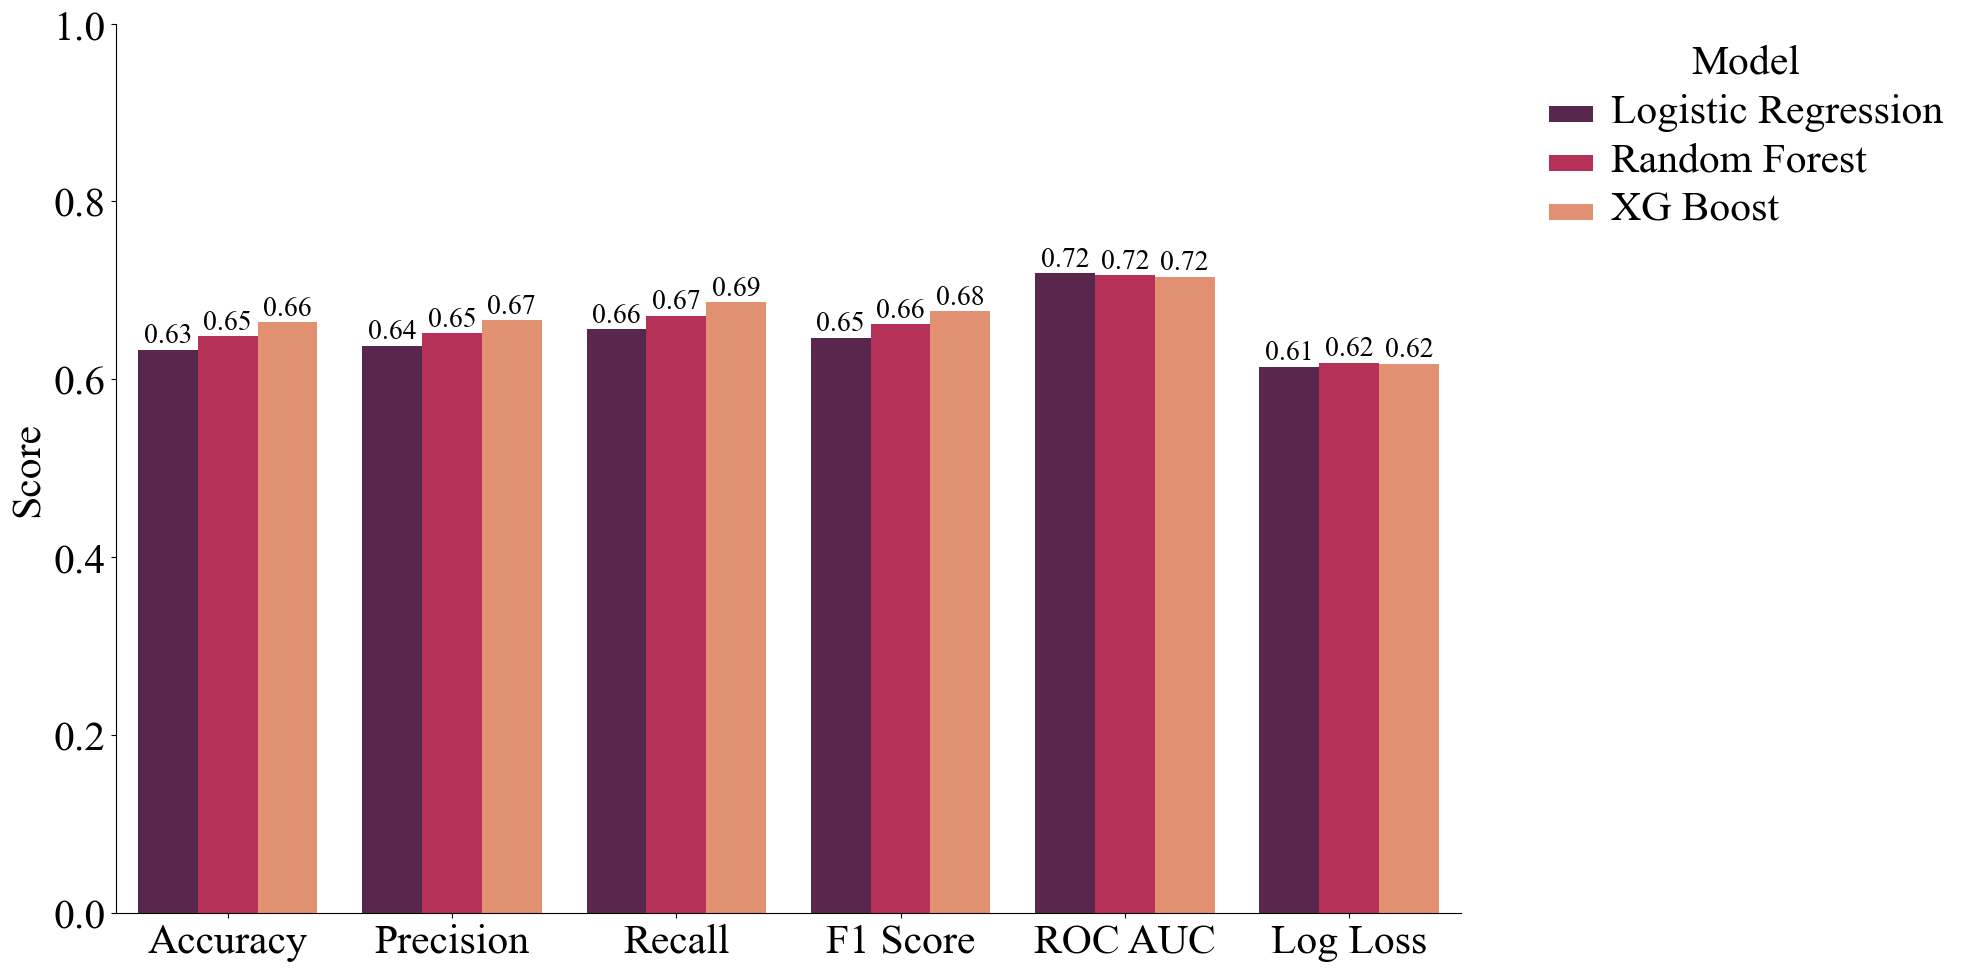

In [22]:
df_full = combined_df[combined_df["Set"].str.startswith("Test_")].copy()

df_full["Model"] = df_full["Set"].str.replace("Test_", "")
model_map = {
    "LR": "Logistic Regression",
    "RF": "Random Forest",
    "XG": "XG Boost"}

df_full["Model"] = df_full["Model"].map(model_map)

metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC", "Log Loss"]
df_long_full = df_full.melt(id_vars="Model", value_vars=metrics, var_name="Metric", value_name="Value")

plt.figure(figsize=(20, 10))

ax = sns.barplot(
    data=df_long_full,
    x="Metric",
    y="Value",
    hue="Model",
    palette="rocket"
)

ax.set_ylim(0, 1.0)

# Axis fonts
ax.tick_params(axis="x", labelsize=30)
ax.tick_params(axis="y", labelsize=30)
ax.set_ylabel("Score", fontsize=30)
ax.set_xlabel("", fontsize=30)

# Legend
legend = ax.legend(
    title="Model",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    frameon=True
)

legend.get_frame().set_facecolor("none")
legend.get_frame().set_edgecolor("none")
legend.get_frame().set_alpha(0)

legend.set_title("Model", prop={"size": 30})
for text in legend.get_texts():
    text.set_fontsize(30)

sns.despine(ax=ax)

# Bar labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=1, fontsize=20)

plt.tight_layout()
plt.gcf().patch.set_alpha(0)

plt.savefig(
    "classifiercomp_transparent.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)
plt.show()


#### Classification Counts - McNemar's Tet

In [23]:
df_merged_full = pd.concat(
    [dummy_results, df_results_XG, df_results_LR, df_results_RF], axis=1)

df_merged_full.head()

,y_true_dummy,y_pred_dummy,Classifier_Correct_dummy,y_true_xg,y_pred_xg,Classifier_Correct_xg,y_true_LR,y_pred_LR,Classifier_Correct_lr,y_true_RF,y_pred_RF,Classifier_Correct_RF
0,1,1,yes,1,0,no,1,0,no,1,0,no
1,1,1,yes,1,1,yes,1,1,yes,1,1,yes
2,0,1,no,0,0,yes,0,0,yes,0,0,yes
3,0,1,no,0,1,no,0,1,no,0,1,no
4,1,1,yes,1,1,yes,1,1,yes,1,1,yes


In [24]:
print(df_merged_full["Classifier_Correct_dummy"].value_counts())
print(df_merged_full["Classifier_Correct_xg"].value_counts())
print(df_merged_full["Classifier_Correct_lr"].value_counts())
print(df_merged_full["Classifier_Correct_RF"].value_counts())

Classifier_Correct_dummy
yes    67
no     64
Name: count, dtype: int64
Classifier_Correct_xg
yes    87
no     44
Name: count, dtype: int64
Classifier_Correct_lr
yes    83
no     48
Name: count, dtype: int64
Classifier_Correct_RF
yes    85
no     46
Name: count, dtype: int64


In [25]:
## Dummy vs XGFull
contingency_table_raw1 = pd.crosstab(
    df_merged_full["Classifier_Correct_dummy"],
    df_merged_full["Classifier_Correct_xg"]).reindex(index=["yes", "no"], columns=["yes", "no"])

print (contingency_table_raw1)

## McNemar"s test
result = mcnemar(contingency_table_raw1, exact=True)

print(f"\nMcNemar’s test statistic = {result.statistic:.3f}, p-value = {result.pvalue:.3f}")
if result.pvalue > alpha:
    print("Same proportions of errors")
else:
    print("Different proportions of errors")

Classifier_Correct_xg     yes  no
Classifier_Correct_dummy         
yes                        46  21
no                         41  23

McNemar’s test statistic = 21.000, p-value = 0.015
Different proportions of errors


In [26]:
## Dummy vs LR
contingency_table_raw1 = pd.crosstab(
    df_merged_full["Classifier_Correct_dummy"],
    df_merged_full["Classifier_Correct_lr"]).reindex(index=["yes", "no"], columns=["yes", "no"])

print (contingency_table_raw1)

## McNemar"s test
result = mcnemar(contingency_table_raw1, exact=True)

print(f"\nMcNemar’s test statistic = {result.statistic:.3f}, p-value = {result.pvalue:.3f}")
if result.pvalue > alpha:
    print("Same proportions of errors")
else:
    print("Different proportions of errors")

Classifier_Correct_lr     yes  no
Classifier_Correct_dummy         
yes                        44  23
no                         39  25

McNemar’s test statistic = 23.000, p-value = 0.056
Same proportions of errors


In [27]:
## Dummy vs RF
contingency_table_raw1 = pd.crosstab(
    df_merged_full["Classifier_Correct_dummy"],
    df_merged_full["Classifier_Correct_RF"]).reindex(index=["yes", "no"], columns=["yes", "no"])

print (contingency_table_raw1)

## McNemar"s test
result = mcnemar(contingency_table_raw1, exact=True)

print(f"\nMcNemar’s test statistic = {result.statistic:.3f}, p-value = {result.pvalue:.3f}")
if result.pvalue > alpha:
    print("Same proportions of errors")
else:
    print("Different proportions of errors")

Classifier_Correct_RF     yes  no
Classifier_Correct_dummy         
yes                        45  22
no                         40  24

McNemar’s test statistic = 22.000, p-value = 0.030
Different proportions of errors


In [28]:
## XG vs LRFull
contingency_table_raw2 = pd.crosstab(
    df_merged_full["Classifier_Correct_xg"],
    df_merged_full["Classifier_Correct_lr"]).reindex(index=["yes", "no"], columns=["yes", "no"])

print (contingency_table_raw2)

## McNemar"s test
result = mcnemar(contingency_table_raw2, exact=True)

print(f"\nMcNemar’s test statistic = {result.statistic:.3f}, p-value = {result.pvalue:.3f}")
if result.pvalue > alpha:
    print("Same proportions of errors")
else:
    print("Different proportions of errors")

Classifier_Correct_lr  yes  no
Classifier_Correct_xg         
yes                     74  13
no                       9  35

McNemar’s test statistic = 9.000, p-value = 0.523
Same proportions of errors


In [29]:
## XG vs RF
contingency_table_raw2 = pd.crosstab(
    df_merged_full["Classifier_Correct_xg"],
    df_merged_full["Classifier_Correct_RF"]
).reindex(index=["yes", "no"], columns=["yes", "no"])

print (contingency_table_raw2)

## McNemar"s test
result = mcnemar(contingency_table_raw2, exact=True)

print(f"\nMcNemar’s test statistic = {result.statistic:.3f}, p-value = {result.pvalue:.3f}")
if result.pvalue > alpha:
    print("Same proportions of errors")
else:
    print("Different proportions of errors")

Classifier_Correct_RF  yes  no
Classifier_Correct_xg         
yes                     77  10
no                       8  36

McNemar’s test statistic = 8.000, p-value = 0.815
Same proportions of errors


In [30]:
## LR vs RF
contingency_table_raw2 = pd.crosstab(
    df_merged_full["Classifier_Correct_lr"],
    df_merged_full["Classifier_Correct_RF"]
).reindex(index=["yes", "no"], columns=["yes", "no"])

print (contingency_table_raw2)

## McNemar"s test
result = mcnemar(contingency_table_raw2, exact=True)

print(f"\nMcNemar’s test statistic = {result.statistic:.3f}, p-value = {result.pvalue:.3f}")
if result.pvalue > alpha:
    print("Same proportions of errors")
else:
    print("Different proportions of errors")

Classifier_Correct_RF  yes  no
Classifier_Correct_lr         
yes                     76   7
no                       9  39

McNemar’s test statistic = 7.000, p-value = 0.804
Same proportions of errors


### SHAP Values

In [31]:
## Set up explainer for final model (XGBoost)
explainer_XG1 = shap.Explainer(final_model_XG1, X_train_scaled_XG1, feature_names=feature_names_XG1)

shap_test_XG1 = explainer_XG1(X_test_scaled_XG1)

## SHAP value table
mean_abs_shap_XG1 = np.mean(np.abs(shap_test_XG1.values), axis=0)
feature_importance_XG1 = pd.DataFrame({
    "Feature": feature_names_XG1, 
    "Mean Absolute SHAP value": mean_abs_shap_XG1}).sort_values(by="Mean Absolute SHAP value", ascending=False)

print(feature_importance_XG1.head(10))

## Percentage of total SHAP values 
mean_abs_shap_series = pd.Series(mean_abs_shap_XG1, index=feature_names_XG1)
top_10 = mean_abs_shap_series.sort_values(ascending=False).head(10)
top_10_proportion = top_10.sum() / mean_abs_shap_series.sum()

print(f"Top 10 SHAP features account for {top_10_proportion:.2%} of the total SHAP values.")

                 Feature  Mean Absolute SHAP value
9       lonely_total_new                  0.199287
8               WSAS_pre                  0.171047
12     perc_health_total                  0.143440
37            impact_pca                  0.099830
26   cope_behavdisengage                  0.085715
18         pers_emotstab                  0.079551
14               loc_ext                  0.066563
11  stresslife_total_new                  0.060905
7               GAD7_pre                  0.060713
33       cope_self_blame                  0.060324
Top 10 SHAP features account for 72.18% of the total SHAP values.


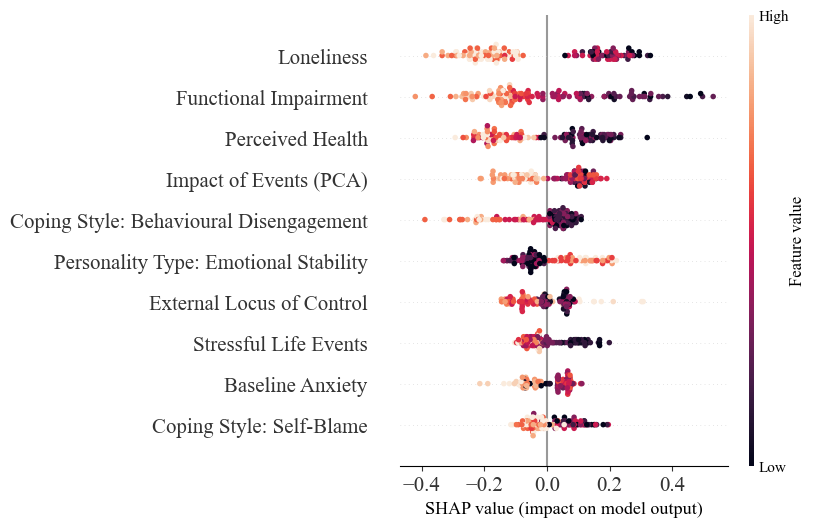

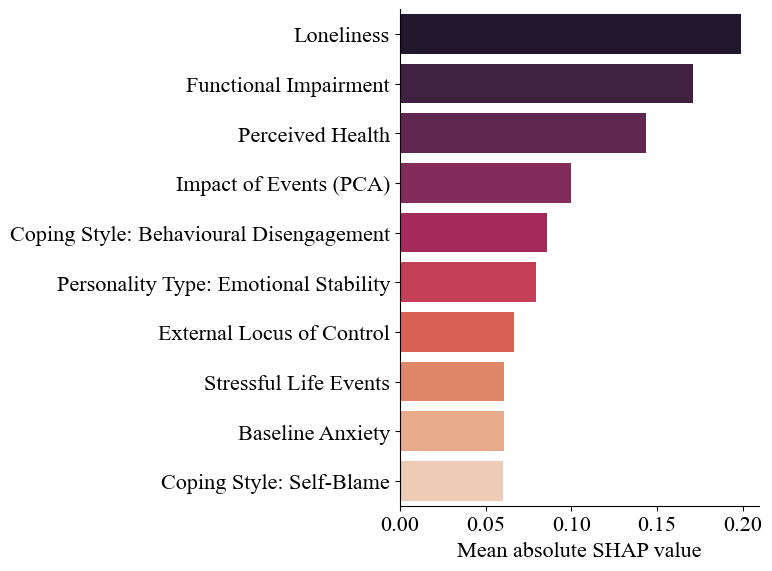

In [32]:
names_clean = {
    "perc_health_total": "Perceived Health",
    "lonely_total_new": "Loneliness",
    "WSAS_pre": "Functional Impairment",
    "cope_self_blame": "Coping Style: Self-Blame",
    "stresslife_total_new": "Stressful Life Events",
    "cope_behavdisengage": "Coping Style: Behavioural Disengagement",
    "cope_self_distract": "Coping Style: Self Distraction",
    "impact_pca": "Impact of Events (PCA)",
    "pers_emotstab": "Personality Type: Emotional Stability",
    "loc_ext": "External Locus of Control",
    "GAD7_pre": "Baseline Anxiety"}

## Rename columns
clean_names_full = [names_clean.get(col, col) for col in feature_names_XG1]
rocket_cmap = mpl.colors.ListedColormap(sns.color_palette("rocket", 256))


## SHAP heat map
shap.summary_plot(
    shap_test_XG1.values, 
    features=X_test_scaled_XG1, 
    feature_names=clean_names_full,  
    max_display=10,
    show=False,
    cmap=rocket_cmap
)
plt.tight_layout()
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.gcf().patch.set_alpha(0)
plt.savefig(
    "xg_shap_summary1.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)
plt.show()

## SHAP bar chart
top10_features = feature_importance_XG1.head(10).copy()
top10_features["clean Feature"] = top10_features["Feature"].map(names_clean).fillna(top10_features["Feature"])

plt.figure(figsize=(8, 6))
sns.barplot(
    data=top10_features,  
    y="clean Feature", x="Mean Absolute SHAP value", palette="rocket")
plt.title("")
plt.xlabel("Mean absolute SHAP value")
plt.ylabel("")
plt.tight_layout()
sns.despine()
plt.tight_layout()
plt.gcf().patch.set_alpha(0)
plt.savefig(
    "shap_xg_summary2.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)
plt.show()


### Post-hoc analysis

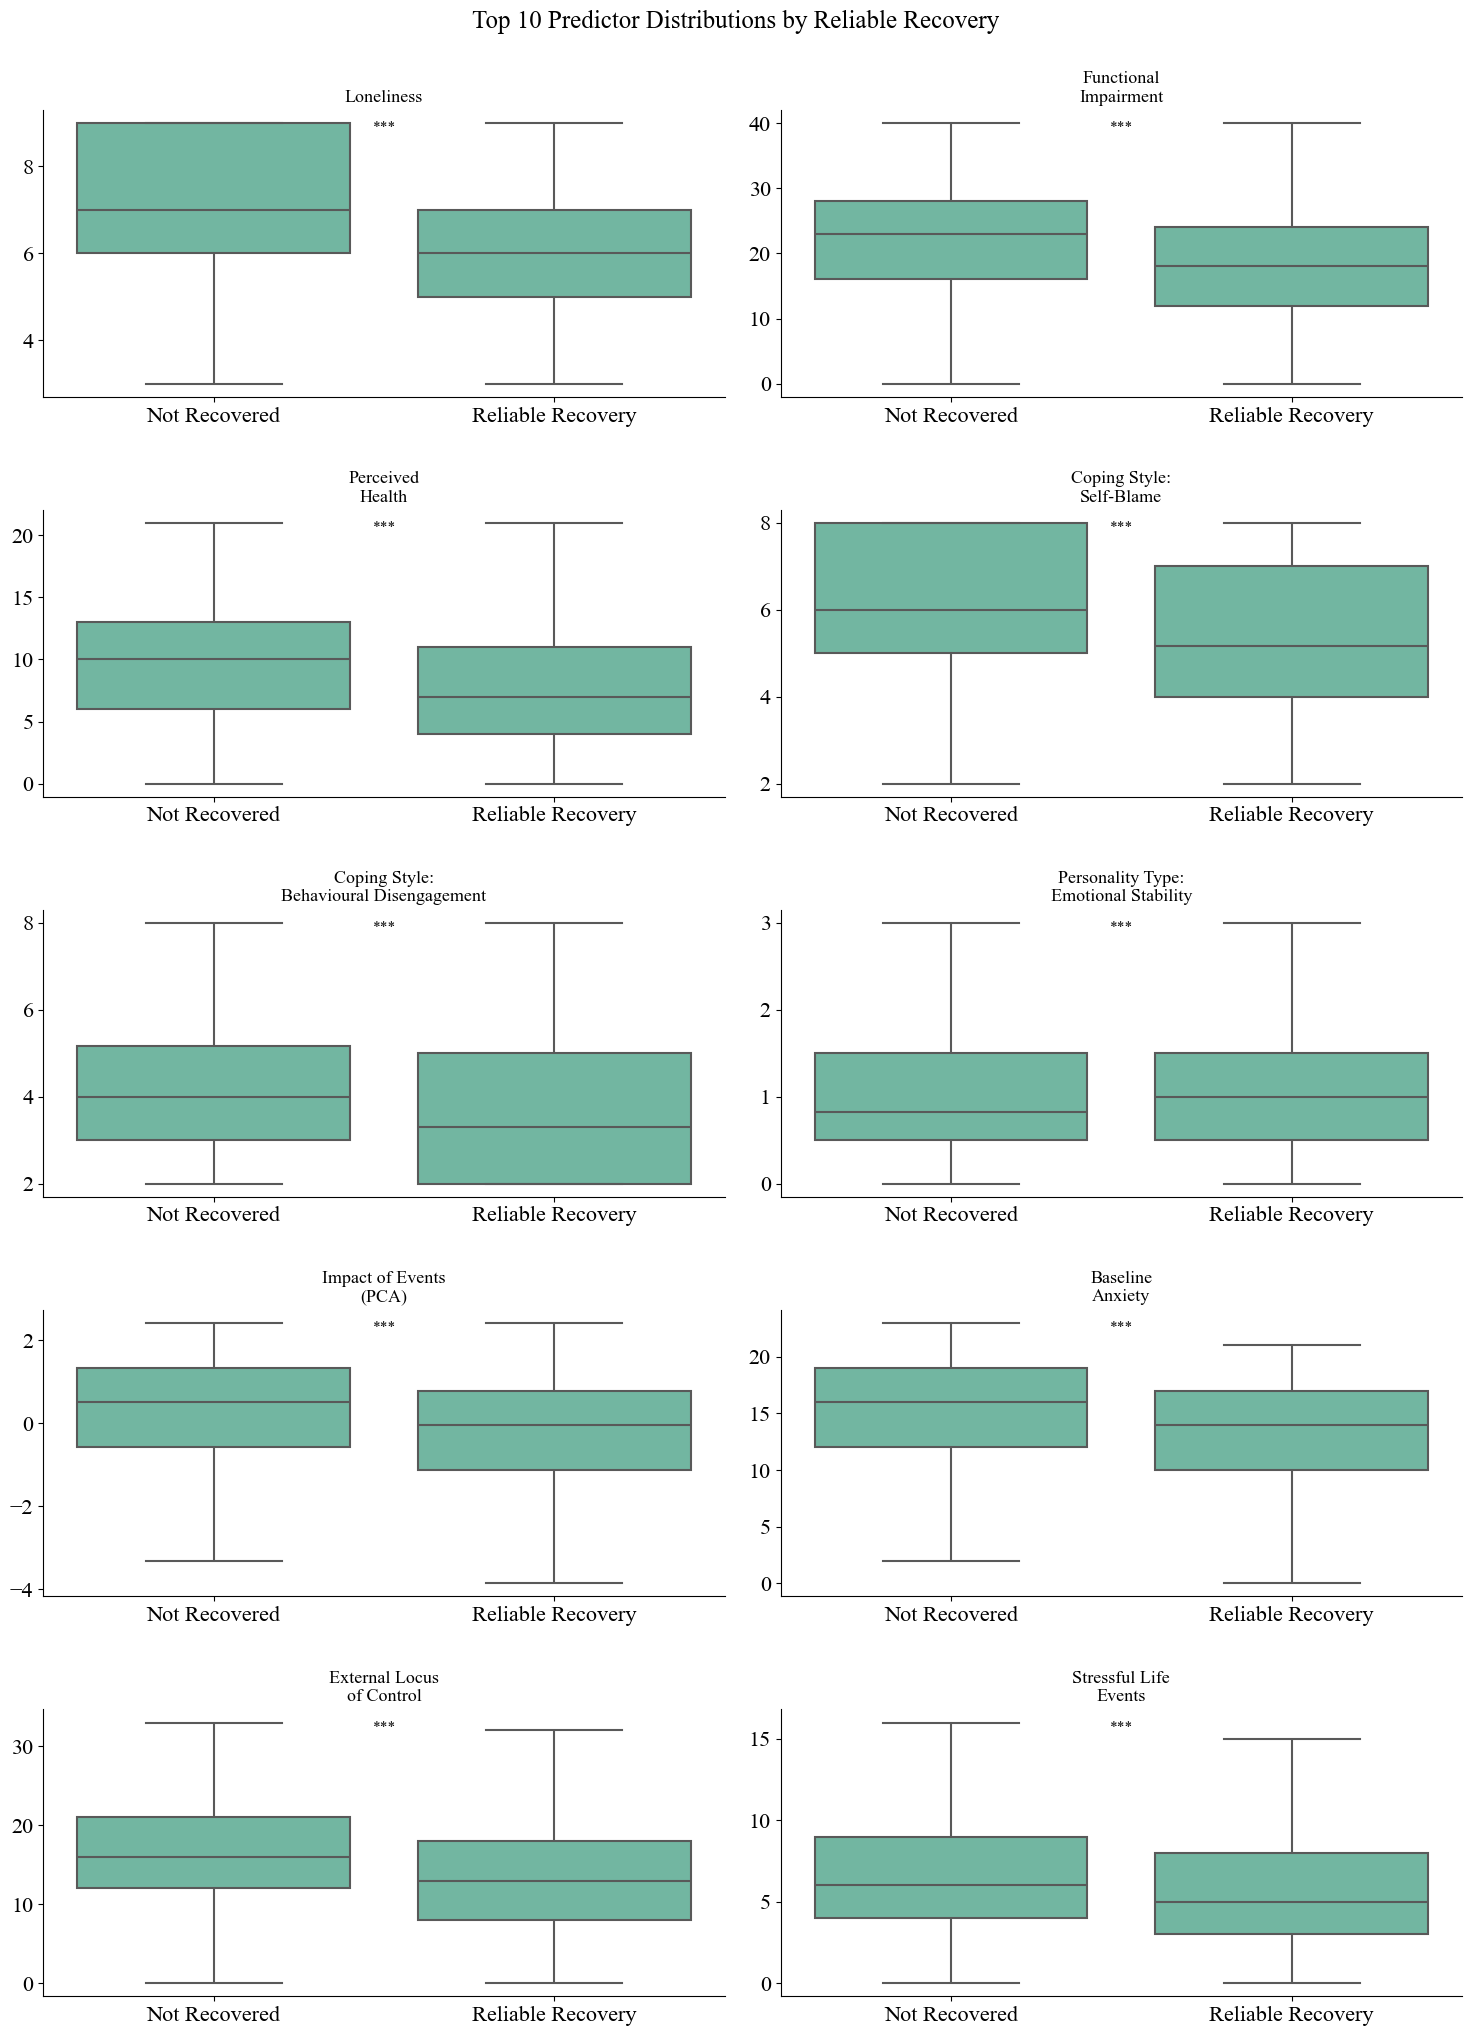

             lonely_total_new             WSAS_pre            \
                         mean       std       mean       std   
rel_recovery                                                   
0.0                  7.065201  1.767235  22.335059  8.350110   
1.0                  6.049822  1.876354  18.095044  8.432461   

             perc_health_total           cope_self_blame            \
                          mean       std            mean       std   
rel_recovery                                                         
0.0                   9.856998  4.821773        5.987518  1.832979   
1.0                   7.737400  4.684717        5.400089  1.879769   

             cope_behavdisengage           pers_emotstab           impact_pca  \
                            mean       std          mean       std       mean   
rel_recovery                                                                    
0.0                     4.382671  1.687490      0.903558  0.790860   0.256353   
1.0 

In [33]:
## Reliable recovery differences
top_features = [
    "lonely_total_new",
    "WSAS_pre",
    "perc_health_total",
    "cope_self_blame",
    "cope_behavdisengage",
    "pers_emotstab",
    "impact_pca",
    "GAD7_pre",
    "loc_ext",
    "stresslife_total_new"]

ncols = 2
nrows = 5

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 20))
axes = axes.flatten()

feature_names = [
    "Loneliness",
    "Functional\nImpairment",
    "Perceived\nHealth",
    "Coping Style:\nSelf-Blame",
    "Coping Style:\nBehavioural Disengagement",
    "Personality Type:\nEmotional Stability",
    "Impact of Events\n(PCA)",
    "Baseline\nAnxiety",
    "External Locus\nof Control",
    "Stressful Life\nEvents"
]

## Boxplots

for i, feature in enumerate(top_features):
    ax = axes[i]
    sns.boxplot(
        x="rel_recovery",
        y=feature,
        data=df_encoded_1,
        ax=ax,
        color="#66c2a5",
        showfliers=False,
        linewidth=1.5)
    
    ax.set_title(feature_names[i], fontsize=13)
    ax.set_xlabel("")
    ax.set_ylabel("")
    
    ## T-test and significance
    groups = df_encoded_1["rel_recovery"].unique()
    if len(groups) == 2:
        data1 = df_encoded_1[df_encoded_1["rel_recovery"] == groups[0]][feature].dropna()
        data2 = df_encoded_1[df_encoded_1["rel_recovery"] == groups[1]][feature].dropna()
        stat, pval = ttest_ind(data1, data2, equal_var=False)
        if pval < 0.001:
            sig = "***"
        elif pval < 0.01:
            sig = "**"
        elif pval < 0.05:
            sig = "*"
        else:
            sig = "ns"
        ax.text(
            0.5, 0.96,
            f"{sig}",
            ha="center", va="top", fontsize=11, color="black",
            transform=ax.transAxes)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Not Recovered", "Reliable Recovery"])
    sns.despine(ax=ax, top=True, right=True)

for j in range(len(top_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(h_pad=2)
plt.subplots_adjust(top=.97)
plt.suptitle("Top 10 Predictor Distributions by Reliable Recovery", fontsize=18, y=1.02)
plt.savefig("top10_posthoc.png", dpi=300, bbox_inches="tight")
plt.show()

grouped_stats = df_encoded_1.groupby("rel_recovery")[top_features].agg(["mean", "std"])
print(grouped_stats)

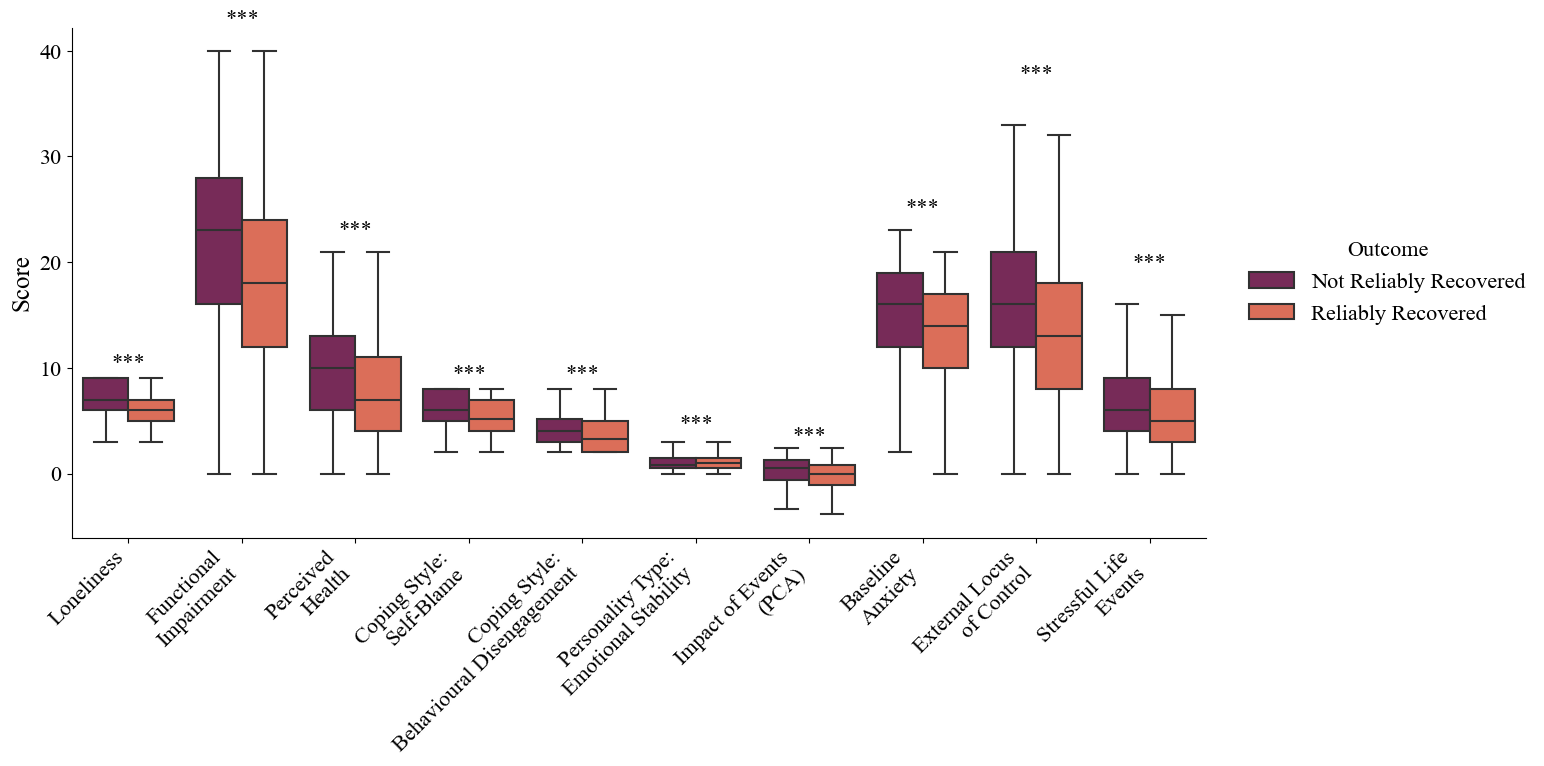

In [42]:
df_long = df_encoded_1.melt(
    id_vars="rel_recovery",
    value_vars=top_features,
    var_name="feature",
    value_name="value"
)

feature_label_map = dict(zip(top_features, feature_names))
df_long["feature"] = df_long["feature"].map(feature_label_map)

## Ensure categorical and ordered hue
df_long["rel_recovery"] = df_long["rel_recovery"].astype(int)
df_long["rel_recovery"] = pd.Categorical(
    df_long["rel_recovery"],
    categories=[0, 1],
    ordered=True
)
rocket_colors = sns.color_palette("rocket", n_colors=2)
palette = {
    0: rocket_colors[0],  ## Not Recovered
    1: rocket_colors[1]   ## Reliable Recovery
}

plt.figure(figsize=(18, 8))
ax = sns.boxplot(
    x="feature",
    y="value",
    hue="rel_recovery",
    data=df_long,
    showfliers=False,
    linewidth=1.5,
    palette=palette,
    hue_order=[0, 1]
)
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_title(
    "",
    fontsize=24
)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

plt.xticks(rotation=45, ha="right")
sns.despine(top=True, right=True)
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    ["Not Reliably Recovered", "Reliably Recovered"],
    title="Outcome",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=16,        
    title_fontsize=16 
)
legend.get_frame().set_facecolor("none")
legend.get_frame().set_edgecolor("none")
legend.get_frame().set_alpha(0)

## Statistical annotations
for i, feature in enumerate(feature_names):

    data_feat = df_long[df_long["feature"] == feature]

    group0 = data_feat[data_feat["rel_recovery"] == 0]["value"].dropna()
    group1 = data_feat[data_feat["rel_recovery"] == 1]["value"].dropna()

    stat, pval = ttest_ind(group0, group1, equal_var=False)

    if pval < 0.001:
        sig = "***"
    elif pval < 0.01:
        sig = "**"
    elif pval < 0.05:
        sig = "*"
    else:
        sig = "ns"

    y_max = data_feat["value"].max()
    ax.text(
        i,
        y_max * 1.05,
        sig,
        ha="center",
        va="bottom",
        fontsize=16
    )
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 24,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "legend.title_fontsize": 16
})
plt.gcf().patch.set_alpha(0)
plt.savefig(
    "top10_transparent.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)
plt.show()


In [35]:
## Create clean table 

values_ttest = []

for feature in top_features:
    not_recovered = df[df["rel_recovery"] == 0][feature]
    recovered = df[df["rel_recovery"] == 1][feature]
    mean_NR = not_recovered.mean()
    mean_R = recovered.mean()
    std_NR= not_recovered.std()
    std_R = recovered.std()
    stat, p = ttest_ind(not_recovered, recovered, nan_policy="omit")
    p_str = "< .001" if p < 0.001 else f"{p:.4f}"
    values_ttest.append({
        "Feature": feature,
        "Not Recovered": f"{mean_NR:.2f} ± {std_NR:.2f}",
        "Recovered": f"{mean_R:.2f} ± {std_R:.2f}",
        "t": f"{stat:.2f}",
        "p": p_str})

table = pd.DataFrame(values_ttest)
print(tabulate(table, headers="keys", tablefmt="github", showindex=False))

| Feature              | Not Recovered   | Recovered    |     t | p      |
|----------------------|-----------------|--------------|-------|--------|
| lonely_total_new     | 7.07 ± 1.77     | 6.05 ± 1.88  |  8.22 | < .001 |
| WSAS_pre             | 22.34 ± 8.35    | 18.10 ± 8.43 |  7.46 | < .001 |
| perc_health_total    | 9.86 ± 4.82     | 7.74 ± 4.68  |  6.59 | < .001 |
| cope_self_blame      | 5.99 ± 1.83     | 5.40 ± 1.88  |  4.67 | < .001 |
| cope_behavdisengage  | 4.38 ± 1.69     | 3.73 ± 1.61  |  5.84 | < .001 |
| pers_emotstab        | 0.90 ± 0.79     | 1.16 ± 0.87  | -4.54 | < .001 |
| impact_pca           | 0.26 ± 1.44     | -0.24 ± 1.55 |  4.89 | < .001 |
| GAD7_pre             | 14.82 ± 4.74    | 13.33 ± 4.43 |  4.79 | < .001 |
| loc_ext              | 16.21 ± 6.77    | 13.56 ± 7.23 |  5.59 | < .001 |
| stresslife_total_new | 6.79 ± 3.60     | 5.90 ± 3.57  |  3.64 | < .001 |


## Exploratory Interaction Terms

In [37]:
for idx, col_name in enumerate(train_df_encoded_1.columns):
    print(idx, col_name)

0 age
1 benefits
2 previous_mh
3 mh_other
4 mh_meds
5 physical_problems
6 PHQ9_pre
7 GAD7_pre
8 WSAS_pre
9 lonely_total_new
10 resilience_total
11 stresslife_total_new
12 perc_health_total
13 loc_int
14 loc_ext
15 pers_extraversion
16 pers_agreeable
17 pers_conscientious
18 pers_emotstab
19 pers_openexp
20 cope_self_distract
21 cope_active
22 cope_denial
23 cope_substuse
24 cope_emotsupp
25 cope_instrsupp
26 cope_behavdisengage
27 cope_venting
28 cope_posreframe
29 cope_planning
30 cope_humour
31 cope_acceptance
32 cope_religion
33 cope_self_blame
34 current_mh_duration_clean
35 education_level_3
36 self_compassion_pca
37 impact_pca
38 gender_1
39 gender_2
40 mh_onset_cat_1
41 ethnicity_3_1
42 condition_clean_1
43 employment_status_3_1
44 employment_status_3_2
45 rel_recovery


### Age

In [39]:
feat_col = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,
            34,35,36,37,38,39,40,42,43,44]
rel_recovery = 45

## Interaction with age
age_train = train_df_1.iloc[:, 0].values
age_val = val_df_1.iloc[:, 0].values
age_test = test_df_1.iloc[:, 0].values

def add_interaction(df, base_cols, interact):
    main = df[:, base_cols]
    ## Make 2D
    interact = interact.reshape(-1, 1)
    interactions = main * interact
    return np.concatenate([main, interactions], axis=1)

X_train_XG4 = add_interaction(train_df, feat_col, age_train)
y_train_XG4 = train_df[:, rel_recovery].astype(int)

X_val_XG4 = add_interaction(val_df, feat_col, age_val)
y_val_XG4 = val_df[:, rel_recovery].astype(int)

X_test_XG4 = add_interaction(test_df, feat_col, age_test)
y_test_XG4 = test_df[:, rel_recovery].astype(int)

In [40]:
## Scale Features
scaler_XG4 = StandardScaler()
X_train_scaled_XG4 = scaler_XG4.fit_transform(X_train_XG4)
X_val_scaled_XG4 = scaler_XG4.transform(X_val_XG4)
X_test_scaled_XG4 = scaler_XG4.transform(X_test_XG4)

## GridSearch
param_grid_XG4 = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7]}

base_model_XG4 = XGBClassifier(random_state=randomstate)
grid_search_XG4 = GridSearchCV(base_model_XG4, param_grid_XG4, cv=5, scoring="roc_auc", n_jobs=-1)
grid_search_XG4.fit(X_train_scaled_XG4, y_train_XG4)

## Optimal hyperparameters 
best_params_XG4 = grid_search_XG4.best_params_
print(f"\nBest Params: {best_params_XG4}")

## 10-Fold CV 
skf_XG4 = StratifiedKFold(n_splits=10, shuffle=True, random_state=randomstate)

f1_scores_XG4 = []
rocauc_scores_XG4 = []
logloss_scores_XG4 = []
all_preds_XG4 = []
all_true_XG4 = []

for fold, (train_idx_XG4, test_idx_XG4) in enumerate(skf_XG4.split(X_train_scaled_XG4, y_train_XG4), 1):
    X_fold_train_XG4 = X_train_scaled_XG4[train_idx_XG4]
    X_fold_test_XG4 = X_train_scaled_XG4[test_idx_XG4]
    y_fold_train_XG4 = y_train_XG4[train_idx_XG4]
    y_fold_test_XG4 = y_train_XG4[test_idx_XG4]

    model_XG4 = XGBClassifier(**best_params_XG4,random_state=randomstate,use_label_encoder=False)
    model_XG4.fit(X_fold_train_XG4, y_fold_train_XG4)

    y_pred_XG4 = model_XG4.predict(X_fold_test_XG4)
    y_proba_XG4 = model_XG4.predict_proba(X_fold_test_XG4)[:, 1] 

    f1_XG4 = f1_score(y_fold_test_XG4, y_pred_XG4)
    f1_scores_XG4.append(f1_XG4)

    rocauc_XG4 = roc_auc_score(y_fold_test_XG4, y_proba_XG4)
    rocauc_scores_XG4.append(rocauc_XG4)

    logloss_XG4 = log_loss(y_fold_test_XG4, y_proba_XG4)
    logloss_scores_XG4.append(logloss_XG4)

    all_preds_XG4.extend(y_pred_XG4)
    all_true_XG4.extend(y_fold_test_XG4)

    print(f"Fold {fold} F1 Score: {f1_XG4:.4f}, ROC AUC: {rocauc_XG4:.4f}, Log Loss: {logloss_XG4:.4f}")

print(f"\nAverage CV F1 Score: {np.mean(f1_scores_XG4):.4f}")
print(f"Average CV ROC AUC: {np.mean(rocauc_scores_XG4):.4f}")
print(f"Average CV Log Loss: {np.mean(logloss_scores_XG4):.4f}")
print("Overall Precision:", precision_score(all_true_XG4, all_preds_XG4))
print("Overall Recall:", recall_score(all_true_XG4, all_preds_XG4))

## Train final model on full training 
final_model_XG4 = XGBClassifier(**best_params_XG4, random_state=randomstate, use_label_encoder=False)
final_model_XG4.fit(X_train_scaled_XG4, y_train_XG4)


## Validation set
y_val_pred_XG4 = final_model_XG4.predict(X_val_scaled_XG4)
y_val_proba_XG4 = final_model_XG4.predict_proba(X_val_scaled_XG4)[:, 1]

val_roc_auc_XG4 = roc_auc_score(y_val_XG4, y_val_proba_XG4)
val_prec_XG4 = precision_score(y_val_XG4, y_val_pred_XG4)
val_rec_XG4 = recall_score(y_val_XG4, y_val_pred_XG4)
val_f1_XG4 = f1_score(y_val_XG4, y_val_pred_XG4)
val_acc_XG4 = accuracy_score(y_val_XG4, y_val_pred_XG4)
val_logloss_XG4 = log_loss(y_val_XG4, y_val_proba_XG4)
val_confmat_XG4 = confusion_matrix(y_val_XG4, y_val_pred_XG4)

print("\nValidation Metrics:")
print(f"Accuracy:     {val_acc_XG4:.4f}")
print(f"Precision:    {val_prec_XG4:.4f}")
print(f"Recall:       {val_rec_XG4:.4f}")
print(f"F1 Score:     {val_f1_XG4:.4f}")
print(f"ROC AUC:      {val_roc_auc_XG4:.4f}")
print(f"Log Loss:     {val_logloss_XG4:.4f}")
print("Confusion Matrix:\n", val_confmat_XG4)
print("\nClassification Report:\n", classification_report(y_val_XG4, y_val_pred_XG4))

## Eval on test set 
y_test_pred_XG4 = final_model_XG4.predict(X_test_scaled_XG4)
y_test_proba6_XG4 = final_model_XG4.predict_proba(X_test_scaled_XG4)[:, 1]

test_roc_auc_XG4 = roc_auc_score(y_test_XG4, y_test_proba6_XG4)
test_prec_XG4 = precision_score(y_test_XG4, y_test_pred_XG4)
test_rec_XG4 = recall_score(y_test_XG4, y_test_pred_XG4)
test_f1_XG4 = f1_score(y_test_XG4, y_test_pred_XG4)
test_acc_XG4 = accuracy_score(y_test_XG4, y_test_pred_XG4)
test_logloss_XG4 = log_loss(y_test_XG4, y_test_proba6_XG4)
test_confmat_XG4 = confusion_matrix(y_test_XG4, y_test_pred_XG4)

print("\nTest Metrics:")
print(f"Accuracy:     {test_acc_XG4:.4f}")
print(f"Precision:    {test_prec_XG4:.4f}")
print(f"Recall:       {test_rec_XG4:.4f}")
print(f"F1 Score:     {test_f1_XG4:.4f}")
print(f"ROC AUC:      {test_roc_auc_XG4:.4f}")
print(f"Log Loss:     {test_logloss_XG4:.4f}")
print("Confusion Matrix:\n", test_confmat_XG4)

results_XG_condition_interaction = {
    "Set": ["Validation_XGUA", "Test_XGUA"],
    "Accuracy": [val_acc_XG4, test_acc_XG4],
    "Precision": [val_prec_XG4, test_prec_XG4],
    "Recall": [val_rec_XG4, test_rec_XG4],
    "F1 Score": [val_f1_XG4, test_f1_XG4],
    "ROC AUC": [val_roc_auc_XG4, test_roc_auc_XG4],
    "Log Loss": [val_logloss_XG4, test_logloss_XG4]}

results_df_XG_condition_interaction = pd.DataFrame(results_XG_condition_interaction)
print(results_df_XG_condition_interaction)


Best Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
Fold 1 F1 Score: 0.5625, ROC AUC: 0.5589, Log Loss: 0.6900
Fold 2 F1 Score: 0.7246, ROC AUC: 0.7742, Log Loss: 0.6223
Fold 3 F1 Score: 0.7419, ROC AUC: 0.7667, Log Loss: 0.6130
Fold 4 F1 Score: 0.6667, ROC AUC: 0.6876, Log Loss: 0.6437
Fold 5 F1 Score: 0.5902, ROC AUC: 0.6505, Log Loss: 0.6499
Fold 6 F1 Score: 0.6230, ROC AUC: 0.6312, Log Loss: 0.6639
Fold 7 F1 Score: 0.6364, ROC AUC: 0.6670, Log Loss: 0.6557
Fold 8 F1 Score: 0.5263, ROC AUC: 0.6153, Log Loss: 0.6747
Fold 9 F1 Score: 0.7385, ROC AUC: 0.7608, Log Loss: 0.6130
Fold 10 F1 Score: 0.6269, ROC AUC: 0.6562, Log Loss: 0.6536

Average CV F1 Score: 0.6437
Average CV ROC AUC: 0.6768
Average CV Log Loss: 0.6480
Overall Precision: 0.6377708978328174
Overall Recall: 0.653968253968254

Validation Metrics:
Accuracy:     0.5878
Precision:    0.6094
Recall:       0.5735
F1 Score:     0.5909
ROC AUC:      0.6557
Log Loss:     0.6514
Confusion Matrix:
 [[38 25]
 [2

                      Feature  Mean Absolute SHAP value
9            lonely_total_new                  0.160442
8                    WSAS_pre                  0.111789
12          perc_health_total                  0.104932
70  cope_behavdisengage_x_age                  0.037542
62        pers_emotstab_x_age                  0.034018
14                    loc_ext                  0.030370
33            cope_self_blame                  0.029651
7                    GAD7_pre                  0.029102
50             PHQ9_pre_x_age                  0.029024
26        cope_behavdisengage                  0.023898


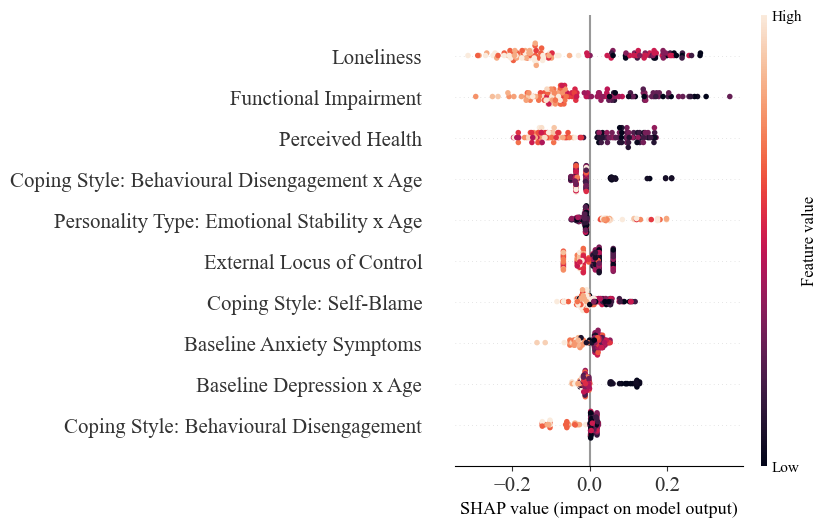

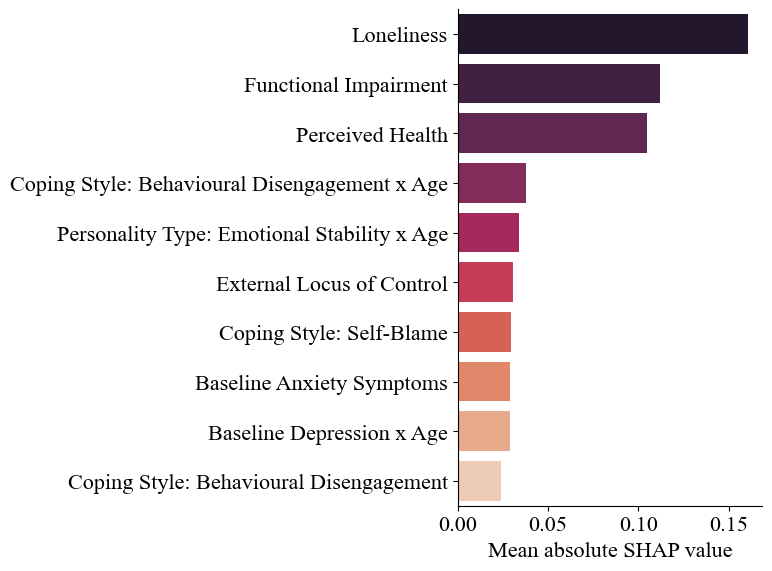

In [41]:
## SHAP 
main_feature_names = [train_df_encoded_1.columns[i] for i in feat_col]

## Add interaction names
age_feature_name = train_df_1.columns[0]
interaction_feature_names = [f"{name}_x_{age_feature_name}" for name in main_feature_names]

feature_names_XG4 = main_feature_names + interaction_feature_names

explainer_XG4 = shap.Explainer(final_model_XG4, X_train_scaled_XG4, feature_names=feature_names_XG4)

shap_test_XG4 = explainer_XG4(X_test_scaled_XG4)

clean_names = {
    "lonely_total_new": "Loneliness",
    "perc_health_total": "Perceived Health",
    "WSAS_pre": "Functional Impairment",
    "cope_self_blame": "Coping Style: Self-Blame",
    "PHQ9_pre_x_age": "Baseline Depression x Age",
    "benefits_x_age": "Benefits Recipient x Age",
    "loc_int_x_age": "Internal Locus of Control x Age",
    "cope_substuse_x_age": "Coping Style: Substance Use x Age",
    "resilience_total_x_age": "Resilience x Age",
    "impact_pca": "Impact of Events (PCA)",
    "self_compassion_pca": "Self-compassion (PCA)",
    "loc_ext": "External Locus of Control",
    "cope_behavdisengage_x_age": "Coping Style: Behavioural Disengagement x Age",
    "pers_emotstab_x_age" : "Personality Type: Emotional Stability x Age",
    "cope_behavdisengage": "Coping Style: Behavioural Disengagement",
    "GAD7_pre" : "Baseline Anxiety Symptoms"}

clean_names_full = [clean_names.get(col, col) for col in feature_names_XG4]


## SHAP VALUES (Feature Importance Table)
mean_abs_shap_XG4 = np.mean(np.abs(shap_test_XG4.values), axis=0)
feature_importance_XG4 = pd.DataFrame({
    "Feature": feature_names_XG4, 
    "Mean Absolute SHAP value": mean_abs_shap_XG4}).sort_values(by="Mean Absolute SHAP value", ascending=False)

print(feature_importance_XG4.head(10))

## Summary plot
shap.summary_plot(
    shap_test_XG4.values, 
    features=X_test_scaled_XG4, 
    feature_names=clean_names_full,  
    max_display = 10,
    show=False,
    cmap=rocket_cmap,
    
)
plt.tight_layout()
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.gcf().patch.set_alpha(0)
plt.savefig(
    "shap_XGclassifier_age_int_summary.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True)
plt.show()

feature_importance_XG4["clean Feature"] = feature_importance_XG4["Feature"].map(lambda x: clean_names.get(x, x))

## Bar chart
plt.figure(figsize=(8, 6))
sns.barplot(
    data=feature_importance_XG4.head(10),  
    y="clean Feature", x="Mean Absolute SHAP value", palette="rocket")
plt.title("")
plt.xlabel("Mean absolute SHAP value")
plt.ylabel("")
plt.tight_layout()
sns.despine()
plt.tight_layout()
plt.gcf().patch.set_alpha(0)
plt.savefig(
    "shap_XGclassifier_age_int_summary2.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True)
plt.show()



Optimization terminated successfully.
         Current function value: 0.669832
         Iterations 5
Simple slopes of cope_behavdisengage at selected ages:
At age 26.61: Slope = -0.246, SE = 0.058, z = -4.21, p = 0.000
At age 43.47: Slope = -0.224, SE = 0.043, z = -5.22, p = 0.000
At age 60.34: Slope = -0.202, SE = 0.064, z = -3.17, p = 0.002


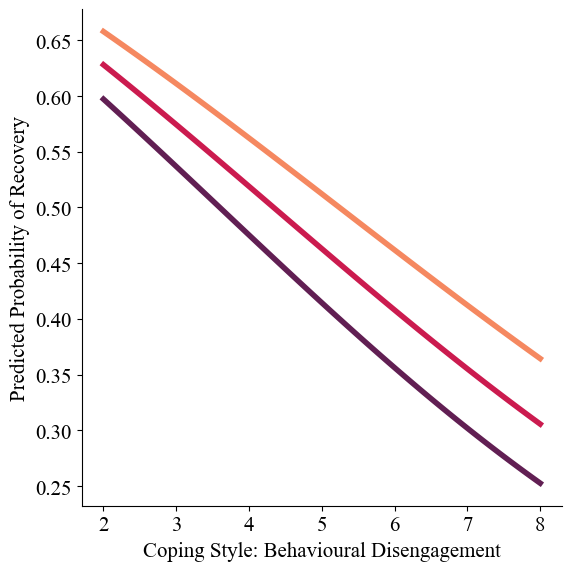

In [42]:
## Coping style × age interaction
model = smf.logit("rel_recovery ~ cope_behavdisengage * age", data=df).fit()
beta = model.params
cov = model.cov_params()

age_mean = df["age"].mean()
age_sd = df["age"].std()
age_vals = [age_mean - age_sd, age_mean, age_mean + age_sd]

print("Simple slopes of cope_behavdisengage at selected ages:")
for age in age_vals:
    slope = beta["cope_behavdisengage"] + beta["cope_behavdisengage:age"] * age
    se = np.sqrt(
        cov.loc["cope_behavdisengage", "cope_behavdisengage"] +
        (age ** 2) * cov.loc["cope_behavdisengage:age", "cope_behavdisengage:age"] +
        2 * age * cov.loc["cope_behavdisengage", "cope_behavdisengage:age"]
    )
    z = slope / se
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    print(f"At age {age:.2f}: Slope = {slope:.3f}, SE = {se:.3f}, z = {z:.2f}, p = {p:.3f}")

## Prediction range
loc_range = np.linspace(
    df["cope_behavdisengage"].min(),
    df["cope_behavdisengage"].max(),
    100
)

## Rocket palette
rocket_palette = sns.color_palette("rocket", n_colors=3)

fig, ax = plt.subplots(figsize=(6, 6))

for i, age in enumerate(age_vals):
    X = pd.DataFrame({
        "cope_behavdisengage": loc_range,
        "age": age
    })
    X["cope_behavdisengage:age"] = X["age"] * X["cope_behavdisengage"]
    pred = model.predict(X)

    ax.plot(
        loc_range,
        pred,
        label=f"Age = {age:.2f}",
        linewidth=4,
        color=rocket_palette[i]
    )

## Aesthetic refinements
ax.set_xlabel("Coping Style: Behavioural Disengagement", fontsize=15)
ax.set_ylabel("Predicted Probability of Recovery", fontsize=15)
ax.tick_params(labelsize=15)

sns.despine(ax=ax)
ax.set_facecolor("none")
fig.patch.set_alpha(0)

fig.tight_layout()
fig.savefig(
    "cope_behavdisengage_age.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

Optimization terminated successfully.
         Current function value: 0.676454
         Iterations 4
Simple slopes of pers_emotstab at selected ages:
At age 26.61: Slope = 0.440, SE = 0.128, z = 3.43, p = 0.001
At age 43.47: Slope = 0.353, SE = 0.085, z = 4.14, p = 0.000
At age 60.34: Slope = 0.266, SE = 0.112, z = 2.36, p = 0.018


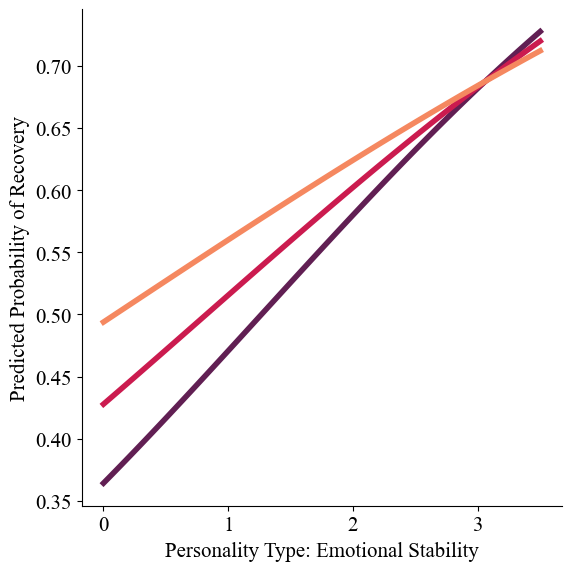

In [43]:
## Personality type × age interaction
model = smf.logit("rel_recovery ~ pers_emotstab * age", data=df).fit()
beta = model.params
cov = model.cov_params()

age_mean = df["age"].mean()
age_sd = df["age"].std()
age_vals = [age_mean - age_sd, age_mean, age_mean + age_sd]

print("Simple slopes of pers_emotstab at selected ages:")
for age in age_vals:
    slope = beta["pers_emotstab"] + beta["pers_emotstab:age"] * age
    se = np.sqrt(
        cov.loc["pers_emotstab", "pers_emotstab"] +
        (age ** 2) * cov.loc["pers_emotstab:age", "pers_emotstab:age"] +
        2 * age * cov.loc["pers_emotstab", "pers_emotstab:age"]
    )
    z = slope / se
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    print(f"At age {age:.2f}: Slope = {slope:.3f}, SE = {se:.3f}, z = {z:.2f}, p = {p:.3f}")

## Prediction range
loc_range = np.linspace(
    df["pers_emotstab"].min(),
    df["pers_emotstab"].max(),
    100
)

## Rocket palette
rocket_palette = sns.color_palette("rocket", n_colors=3)

fig, ax = plt.subplots(figsize=(6, 6))

for i, age in enumerate(age_vals):
    X = pd.DataFrame({
        "pers_emotstab": loc_range,
        "age": age
    })
    X["pers_emotstab:age"] = X["age"] * X["pers_emotstab"]
    pred = model.predict(X)

    ax.plot(
        loc_range,
        pred,
        label=f"Age = {age:.2f}",
        linewidth=4,
        color=rocket_palette[i]
    )

## Aesthetic refinements
ax.set_xlabel("Personality Type: Emotional Stability", fontsize=15)
ax.set_ylabel("Predicted Probability of Recovery", fontsize=15)
ax.tick_params(labelsize=15)



sns.despine(ax=ax)
ax.set_facecolor("none")
fig.patch.set_alpha(0)

fig.tight_layout()
fig.savefig(
    "pers_emotstab.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

Optimization terminated successfully.
         Current function value: 0.649453
         Iterations 5
Simple slopes of PHQ9_pre at selected ages:
At age 26.61: Slope = -0.142, SE = 0.021, z = -6.69, p = 0.000
At age 43.47: Slope = -0.103, SE = 0.014, z = -7.45, p = 0.000
At age 60.34: Slope = -0.065, SE = 0.018, z = -3.59, p = 0.000


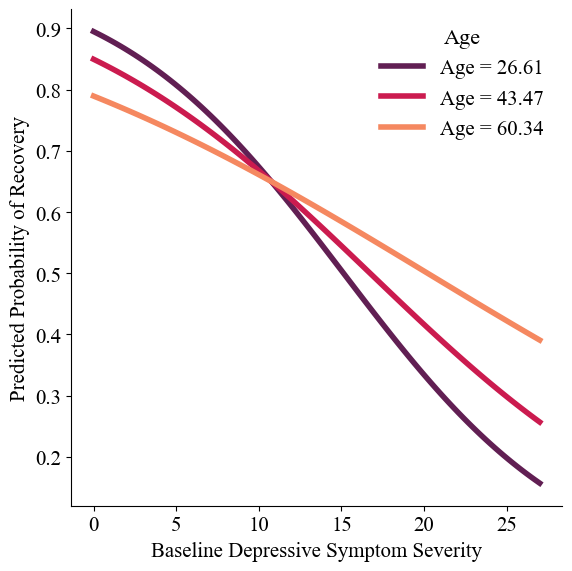

In [44]:
## Depression (PHQ-9) × age interaction
model = smf.logit("rel_recovery ~ PHQ9_pre * age", data=df).fit()
beta = model.params
cov = model.cov_params()

age_mean = df["age"].mean()
age_sd = df["age"].std()
age_vals = [age_mean - age_sd, age_mean, age_mean + age_sd]

print("Simple slopes of PHQ9_pre at selected ages:")
for age in age_vals:
    slope = beta["PHQ9_pre"] + beta["PHQ9_pre:age"] * age
    se = np.sqrt(
        cov.loc["PHQ9_pre", "PHQ9_pre"] +
        (age ** 2) * cov.loc["PHQ9_pre:age", "PHQ9_pre:age"] +
        2 * age * cov.loc["PHQ9_pre", "PHQ9_pre:age"]
    )
    z = slope / se
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    print(f"At age {age:.2f}: Slope = {slope:.3f}, SE = {se:.3f}, z = {z:.2f}, p = {p:.3f}")

## Prediction range
loc_range = np.linspace(
    df["PHQ9_pre"].min(),
    df["PHQ9_pre"].max(),
    100
)

## Rocket palette
rocket_palette = sns.color_palette("rocket", n_colors=3)

fig, ax = plt.subplots(figsize=(6, 6))

for i, age in enumerate(age_vals):
    X = pd.DataFrame({
        "PHQ9_pre": loc_range,
        "age": age
    })
    X["PHQ9_pre:age"] = X["age"] * X["PHQ9_pre"]
    pred = model.predict(X)

    ax.plot(
        loc_range,
        pred,
        label=f"Age = {age:.2f}",
        linewidth=4,
        color=rocket_palette[i]
    )

## Aesthetic refinements
ax.set_xlabel("Baseline Depressive Symptom Severity", fontsize=15)
ax.set_ylabel("Predicted Probability of Recovery", fontsize=15)
ax.tick_params(labelsize=15)

legend = ax.legend(
    frameon=False,
    fontsize=15,
    title="Age"
)

sns.despine(ax=ax)
ax.set_facecolor("none")
fig.patch.set_alpha(0)

fig.tight_layout()
fig.savefig(
    "phq_int_age.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

## Exploratory Stratified Models

### Age Groups

In [45]:
## Split into tertiles
def assign_tertile(age):
    if age < 34.955:
        return 0
    elif age < 51.81:
        return 1
    else:
        return 2

df["age_tertile"] = df["age"].apply(assign_tertile)

In [46]:
## Count the number of people in each group
counts = df["age_tertile"].value_counts().sort_index()
print(counts)

## Calculate the mean age for each tertile category
means = df.groupby("age_tertile")["age"].mean()
print(means)

age_tertile
0    326
1    245
2    302
Name: count, dtype: int64
age_tertile
0    26.055215
1    43.028571
2    62.629139
Name: age, dtype: float64


In [47]:
df_age_1 = df[df["age_tertile"] == 0]
df_age_2 = df[df["age_tertile"] == 1]
df_age_3 = df[df["age_tertile"] == 2]

In [48]:
print(df_age_1.gender.value_counts())
print(df_age_2.gender.value_counts())
df_age_2 = df_age_2[df_age_2["gender"] != 2]
print(df_age_2.gender.value_counts())
print(df_age_3.gender.value_counts())
print(df_age_2.employment_status_3.value_counts())
df_age_2 = df_age_2[df_age_2["employment_status_3"] != 2]

gender
1    253
0     66
2      7
Name: count, dtype: int64
gender
1    174
0     70
2      1
Name: count, dtype: int64
gender
1    174
0     70
Name: count, dtype: int64
gender
1    206
0     96
Name: count, dtype: int64
employment_status_3
0    177
1     66
2      1
Name: count, dtype: int64


#### Age_1

In [49]:
## Split into train (70%), Validation (15%), and Test (15%
train_df_age_1, rem_df_age_1 = train_test_split(df_age_1, train_size=0.7, 
                                                          stratify=df_age_1["rel_recovery"], random_state=randomstate)

val_df_age_1, test_df_age_1 = train_test_split(rem_df_age_1, train_size=0.5, 
                                                         stratify=rem_df_age_1["rel_recovery"], random_state=randomstate)

In [50]:
## One-hot encode categorical variables

df_age_1_encoded = pd.get_dummies(df_age_1, columns=["gender", "mh_onset_cat", "ethnicity_3", "condition_clean",
                                         "employment_status_3"], drop_first=True)

train_df_age_1_encoded = pd.get_dummies(train_df_age_1, columns=["gender", "mh_onset_cat", "ethnicity_3", "condition_clean",
                                         "employment_status_3"], drop_first=True)

val_df_age_1_encoded = pd.get_dummies(val_df_age_1, columns=["gender", "mh_onset_cat", "ethnicity_3", "condition_clean",
                                         "employment_status_3"], drop_first=True)

test_df_age_1_encoded = pd.get_dummies(test_df_age_1, columns=["gender", "mh_onset_cat", "ethnicity_3", "condition_clean",
                                         "employment_status_3"], drop_first=True)


In [51]:
for idx, col_name in enumerate(df_age_1_encoded.columns):
    print(idx, col_name)

0 age
1 benefits
2 previous_mh
3 mh_other
4 mh_meds
5 physical_problems
6 PHQ9_pre
7 GAD7_pre
8 WSAS_pre
9 lonely_total_new
10 selfcomp_total
11 sc_recsuffer
12 sc_universality
13 sc_feeling
14 sc_tolerance
15 sc_action
16 resilience_total
17 stresslife_total_new
18 perc_health_total
19 loc_int
20 loc_ext
21 pers_extraversion
22 pers_agreeable
23 pers_conscientious
24 pers_emotstab
25 pers_openexp
26 cope_self_distract
27 cope_active
28 cope_denial
29 cope_substuse
30 cope_emotsupp
31 cope_instrsupp
32 cope_behavdisengage
33 cope_venting
34 cope_posreframe
35 cope_planning
36 cope_humour
37 cope_acceptance
38 cope_religion
39 cope_self_blame
40 impact_total
41 impact_intrusion
42 impact_avoidance
43 impact_hyperarousal
44 rel_recovery
45 current_mh_duration_clean
46 education_level_3
47 self_compassion_pca
48 impact_pca
49 age_tertile
50 gender_1
51 gender_2
52 mh_onset_cat_1
53 ethnicity_3_1
54 condition_clean_1
55 employment_status_3_1


In [52]:
all_features_age = [1,2,3,4,5,6,7,8,9,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,
                    45,46,47,48,50,51,52,53,54,55,44]

df_age_1_encoded_1 = df_age_1_encoded.iloc[:, all_features_age].copy()
train_df_age_1_encoded_1 = train_df_age_1_encoded.iloc[:, all_features_age].copy()
val_df_age_1_encoded_1 = val_df_age_1_encoded.iloc[:, all_features_age].copy()
test_df_age_1_encoded_1 = test_df_age_1_encoded.iloc[:, all_features_age].copy()

data_df_age_1 = np.array(df_age_1_encoded_1)
train_df_age_1 = np.array(train_df_age_1_encoded_1)
val_df_age_1 = np.array(val_df_age_1_encoded_1)
test_df_age_1 = np.array(test_df_age_1_encoded_1)

In [53]:
## All Features
feat_col_full = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,
                32,33,34,35,36,37,38,39,40,41,42]

rel_recovery = 43
feature_names_age_1 = test_df_age_1_encoded_1.columns[feat_col_full]

X_train_age_1 = train_df_age_1[:, feat_col_full]
y_train_age_1 = train_df_age_1[:, rel_recovery].astype(int)

X_val_age_1 = val_df_age_1[:, feat_col_full]
y_val_age_1 = val_df_age_1[:, rel_recovery].astype(int)

X_test_age_1 = test_df_age_1[:, feat_col_full]
y_test_age_1 = test_df_age_1[:, rel_recovery].astype(int)

print(f"Train: {X_train_age_1.shape[0]}, Val: {X_val_age_1.shape[0]}, Test: {X_test_age_1.shape[0]}")
print(f"Train: {X_train_age_1.shape[1]}, Val: {X_val_age_1.shape[1]}, Test: {X_test_age_1.shape[1]}")


Train: 228, Val: 49, Test: 49
Train: 43, Val: 43, Test: 43


In [54]:
## Scale Features
scaler_age_1 = StandardScaler()
X_train_scaled_age_1 = scaler_age_1.fit_transform(X_train_age_1)
X_val_scaled_age_1 = scaler_age_1.transform(X_val_age_1)
X_test_scaled_age_1 = scaler_age_1.transform(X_test_age_1)

## GridSearch
param_grid_age_1 = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7]}

base_model_age_1 = XGBClassifier(random_state=randomstate)
grid_search_age_1 = GridSearchCV(base_model_age_1, param_grid_age_1, cv=5, scoring="roc_auc", n_jobs=-1)
grid_search_age_1.fit(X_train_scaled_age_1, y_train_age_1)

## Optimal hyperparameteres
best_params_age_1 = grid_search_age_1.best_params_
print(f"\nBest Params: {best_params_age_1}")

## 10-Fold CV 
skf_age_1 = StratifiedKFold(n_splits=10, shuffle=True, random_state=randomstate)

f1_scores_age_1 = []
rocauc_scores_age_1 = []
logloss_scores_age_1 = []
all_preds_age_1 = []
all_true_age_1 = []

for fold, (train_idx_age_1, test_idx_age_1) in enumerate(skf_age_1.split(X_train_scaled_age_1, y_train_age_1), 1):
    X_fold_train_age_1 = X_train_scaled_age_1[train_idx_age_1]
    X_fold_test_age_1 = X_train_scaled_age_1[test_idx_age_1]
    y_fold_train_age_1 = y_train_age_1[train_idx_age_1]
    y_fold_test_age_1 = y_train_age_1[test_idx_age_1]

    model_age_1 = XGBClassifier(**best_params_age_1,random_state=randomstate,use_label_encoder=False)
    model_age_1.fit(X_fold_train_age_1, y_fold_train_age_1)

    y_pred_age_1 = model_age_1.predict(X_fold_test_age_1)
    y_proba_age_1 = model_age_1.predict_proba(X_fold_test_age_1)[:, 1]  

    f1_age_1 = f1_score(y_fold_test_age_1, y_pred_age_1)
    f1_scores_age_1.append(f1_age_1)

    rocauc_age_1 = roc_auc_score(y_fold_test_age_1, y_proba_age_1)
    rocauc_scores_age_1.append(rocauc_age_1)

    logloss_age_1 = log_loss(y_fold_test_age_1, y_proba_age_1)
    logloss_scores_age_1.append(logloss_age_1)

    all_preds_age_1.extend(y_pred_age_1)
    all_true_age_1.extend(y_fold_test_age_1)

    print(f"Fold {fold} F1 Score: {f1_age_1:.4f}, ROC AUC: {rocauc_age_1:.4f}, Log Loss: {logloss_age_1:.4f}")

print(f"\nAverage CV F1 Score: {np.mean(f1_scores_age_1):.4f}")
print(f"Average CV ROC AUC: {np.mean(rocauc_scores_age_1):.4f}")
print(f"Average CV Log Loss: {np.mean(logloss_scores_age_1):.4f}")
print("Overall Precision:", precision_score(all_true_age_1, all_preds_age_1))
print("Overall Recall:", recall_score(all_true_age_1, all_preds_age_1))

## Final model evaluation on training set
final_model_age_1 = XGBClassifier(**best_params_age_1, random_state=randomstate, use_label_encoder=False)
final_model_age_1.fit(X_train_scaled_age_1, y_train_age_1)


## Validation set
y_val_pred_age_1 = final_model_age_1.predict(X_val_scaled_age_1)
y_val_proba_age_1 = final_model_age_1.predict_proba(X_val_scaled_age_1)[:, 1]

val_roc_auc_age_1 = roc_auc_score(y_val_age_1, y_val_proba_age_1)
val_prec_age_1 = precision_score(y_val_age_1, y_val_pred_age_1)
val_rec_age_1 = recall_score(y_val_age_1, y_val_pred_age_1)
val_f1_age_1 = f1_score(y_val_age_1, y_val_pred_age_1)
val_acc_age_1 = accuracy_score(y_val_age_1, y_val_pred_age_1)
val_logloss_age_1 = log_loss(y_val_age_1, y_val_proba_age_1)
val_confmat_age_1 = confusion_matrix(y_val_age_1, y_val_pred_age_1)

print("\nValidation Metrics:")
print(f"Accuracy:     {val_acc_age_1:.4f}")
print(f"Precision:    {val_prec_age_1:.4f}")
print(f"Recall:       {val_rec_age_1:.4f}")
print(f"F1 Score:     {val_f1_age_1:.4f}")
print(f"ROC AUC:      {val_roc_auc_age_1:.4f}")
print(f"Log Loss:     {val_logloss_age_1:.4f}")
print("Confusion Matrix:\n", val_confmat_age_1)
print("\nClassification Report:\n", classification_report(y_val_age_1, y_val_pred_age_1))

## Test set
y_test_pred_age_1 = final_model_age_1.predict(X_test_scaled_age_1)
y_test_proba5_age_1 = final_model_age_1.predict_proba(X_test_scaled_age_1)[:, 1]

test_roc_auc_age_1 = roc_auc_score(y_test_age_1, y_test_proba5_age_1)
test_prec_age_1 = precision_score(y_test_age_1, y_test_pred_age_1)
test_rec_age_1 = recall_score(y_test_age_1, y_test_pred_age_1)
test_f1_age_1 = f1_score(y_test_age_1, y_test_pred_age_1)
test_acc_age_1 = accuracy_score(y_test_age_1, y_test_pred_age_1)
test_logloss_age_1 = log_loss(y_test_age_1, y_test_proba5_age_1)
test_confmat_age_1 = confusion_matrix(y_test_age_1, y_test_pred_age_1)

print("\nTest Metrics:")
print(f"Accuracy:     {test_acc_age_1:.4f}")
print(f"Precision:    {test_prec_age_1:.4f}")
print(f"Recall:       {test_rec_age_1:.4f}")
print(f"F1 Score:     {test_f1_age_1:.4f}")
print(f"ROC AUC:      {test_roc_auc_age_1:.4f}")
print(f"Log Loss:     {test_logloss_age_1:.4f}")
print("Confusion Matrix:\n", test_confmat_age_1)

results_age_1 = {
    "Set": ["Validation_XGFull", "Test_XGFull"],
    "Accuracy": [val_acc_age_1, test_acc_age_1],
    "Precision": [val_prec_age_1, test_prec_age_1],
    "Recall": [val_rec_age_1, test_rec_age_1],
    "F1 Score": [val_f1_age_1, test_f1_age_1],
    "ROC AUC": [val_roc_auc_age_1, test_roc_auc_age_1],
    "Log Loss": [val_logloss_age_1, test_logloss_age_1]}

## Save validation and test metrics and test set predictions/true values
results_df_XGage_1 = pd.DataFrame(results_age_1)
print(results_df_XGage_1)


Best Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}
Fold 1 F1 Score: 0.6316, ROC AUC: 0.7538, Log Loss: 0.5899
Fold 2 F1 Score: 0.6316, ROC AUC: 0.7538, Log Loss: 0.5928
Fold 3 F1 Score: 0.4762, ROC AUC: 0.6077, Log Loss: 0.7017
Fold 4 F1 Score: 0.5714, ROC AUC: 0.6061, Log Loss: 0.6932
Fold 5 F1 Score: 0.4444, ROC AUC: 0.5833, Log Loss: 0.6795
Fold 6 F1 Score: 0.5455, ROC AUC: 0.5303, Log Loss: 0.7585
Fold 7 F1 Score: 0.5714, ROC AUC: 0.6667, Log Loss: 0.6804
Fold 8 F1 Score: 0.8182, ROC AUC: 0.8409, Log Loss: 0.5605
Fold 9 F1 Score: 0.4762, ROC AUC: 0.5250, Log Loss: 0.8035
Fold 10 F1 Score: 0.7778, ROC AUC: 0.8667, Log Loss: 0.5498

Average CV F1 Score: 0.5944
Average CV ROC AUC: 0.6734
Average CV Log Loss: 0.6610
Overall Precision: 0.6185567010309279
Overall Recall: 0.5714285714285714

Validation Metrics:
Accuracy:     0.6939
Precision:    0.7333
Recall:       0.5000
F1 Score:     0.5946
ROC AUC:      0.7660
Log Loss:     0.5765
Confusion Matrix:
 [[23  4]
 [

                 Feature  Mean Absolute SHAP value
5               PHQ9_pre                  0.290431
10  stresslife_total_new                  0.228364
36            impact_pca                  0.226827
12               loc_int                  0.216808
13               loc_ext                  0.135195
17         pers_emotstab                  0.124939
32       cope_self_blame                  0.119323
27       cope_posreframe                  0.098761
3                mh_meds                  0.080972
4      physical_problems                  0.075376


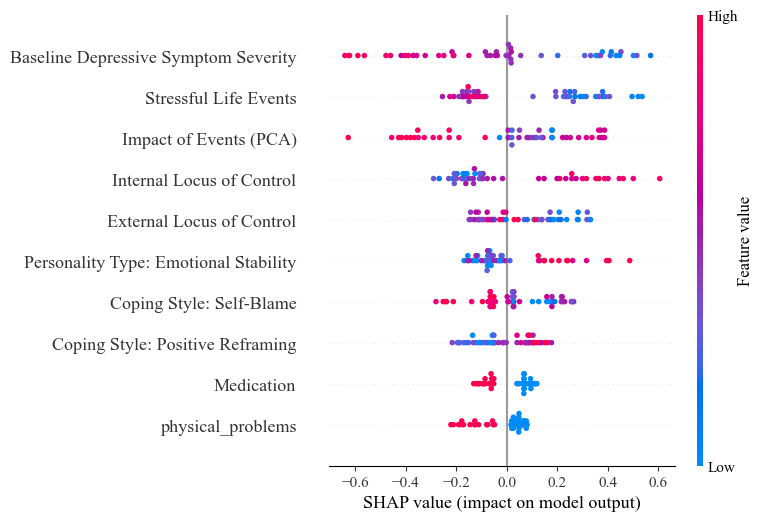

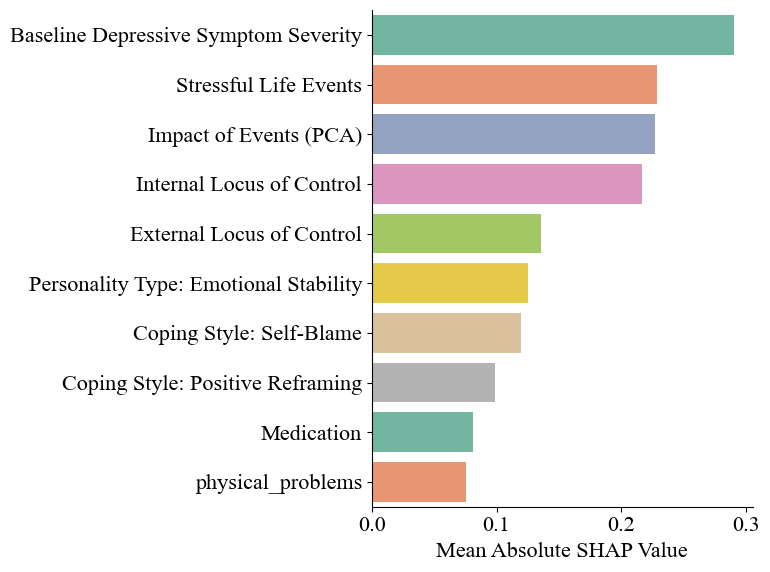

In [55]:
## SHAP Values
explainer_age_1 = shap.Explainer(final_model_age_1, X_train_scaled_age_1, feature_names=feature_names_age_1)

shap_test_age_1 = explainer_age_1(X_test_scaled_age_1)

## SHAP VALUES 
mean_abs_shap_age_1 = np.mean(np.abs(shap_test_age_1.values), axis=0)
feature_importance_age_1 = pd.DataFrame({
    "Feature": feature_names_age_1, 
    "Mean Absolute SHAP value": mean_abs_shap_age_1
}).sort_values(by="Mean Absolute SHAP value", ascending=False)

print(feature_importance_age_1.head(10))

clean_map = {
    "impact_pca": "Impact of Events (PCA)",
    "loc_int": "Internal Locus of Control",
    "stresslife_total_new": "Stressful Life Events",
    "loc_ext": "External Locus of Control",
    "pers_emotstab": "Personality Type: Emotional Stability",
    "cope_substuse": "Coping Style: Substance Use",
    "mh_meds": "Medication",
    "PHQ9_pre": "Baseline Depressive Symptom Severity",
    "cope_posreframe": "Coping Style: Positive Reframing",
    "cope_self_blame": "Coping Style: Self-Blame"}

clean_names_full = [clean_map.get(col, col) for col in feature_names_age_1]

## Summary Plot
shap.summary_plot(
    shap_test_age_1.values, 
    features=X_test_scaled_age_1, 
    feature_names=clean_names_full,  
    max_display=10,
    show=False)

plt.tight_layout()
plt.savefig("shap_XGage_1_summary.png", dpi=300, bbox_inches="tight")
plt.show()

top10_features = feature_importance_age_1.head(10).copy()
top10_features["clean Feature"] = top10_features["Feature"].map(clean_map).fillna(top10_features["Feature"])

## Barchart
plt.figure(figsize=(8, 6))
sns.barplot(
    data=top10_features,  
    y="clean Feature", x="Mean Absolute SHAP value", palette="Set2"
)
plt.title("")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("")
plt.tight_layout()
sns.despine()
plt.savefig("shap_XGage_1_summary2.png", dpi=300, bbox_inches="tight")
plt.show()



#### Age_2

In [56]:
## Split into train (70%), Validation (15%), and Test (15%
train_df_age_2, rem_df_age_2 = train_test_split(df_age_2, train_size=0.7, 
                                                          stratify=df_age_2["rel_recovery"], random_state=randomstate)

val_df_age_2, test_df_age_2 = train_test_split(rem_df_age_2, train_size=0.5, 
                                                         stratify=rem_df_age_2["rel_recovery"], random_state=randomstate)

In [57]:
## One-hot encode categorical variables

df_age_2_encoded = pd.get_dummies(df_age_2, columns=["gender", "mh_onset_cat", "ethnicity_3", "condition_clean",
                                         "employment_status_3"], drop_first=True)

train_df_age_2_encoded = pd.get_dummies(train_df_age_2, columns=["gender", "mh_onset_cat", "ethnicity_3", "condition_clean",
                                         "employment_status_3"], drop_first=True)

val_df_age_2_encoded = pd.get_dummies(val_df_age_2, columns=["gender", "mh_onset_cat", "ethnicity_3", "condition_clean",
                                         "employment_status_3"], drop_first=True)

test_df_age_2_encoded = pd.get_dummies(test_df_age_2, columns=["gender", "mh_onset_cat", "ethnicity_3", "condition_clean",
                                         "employment_status_3"], drop_first=True)


In [58]:
all_features_age = [1,2,3,4,5,6,7,8,9,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,
                    45,46,47,48,50,51,52,53,54,44]

df_age_2_encoded_1 = df_age_2_encoded.iloc[:, all_features_age].copy()
train_df_age_2_encoded_1 = train_df_age_2_encoded.iloc[:, all_features_age].copy()
val_df_age_2_encoded_1 = val_df_age_2_encoded.iloc[:, all_features_age].copy()
test_df_age_2_encoded_1 = test_df_age_2_encoded.iloc[:, all_features_age].copy()

data_df_age_2 = np.array(df_age_2_encoded_1)
train_df_age_2 = np.array(train_df_age_2_encoded_1)
val_df_age_2 = np.array(val_df_age_2_encoded_1)
test_df_age_2 = np.array(test_df_age_2_encoded_1)

In [59]:
for idx, col_name in enumerate(df_age_2_encoded_1.columns):
    print(idx, col_name)

0 benefits
1 previous_mh
2 mh_other
3 mh_meds
4 physical_problems
5 PHQ9_pre
6 GAD7_pre
7 WSAS_pre
8 lonely_total_new
9 resilience_total
10 stresslife_total_new
11 perc_health_total
12 loc_int
13 loc_ext
14 pers_extraversion
15 pers_agreeable
16 pers_conscientious
17 pers_emotstab
18 pers_openexp
19 cope_self_distract
20 cope_active
21 cope_denial
22 cope_substuse
23 cope_emotsupp
24 cope_instrsupp
25 cope_behavdisengage
26 cope_venting
27 cope_posreframe
28 cope_planning
29 cope_humour
30 cope_acceptance
31 cope_religion
32 cope_self_blame
33 current_mh_duration_clean
34 education_level_3
35 self_compassion_pca
36 impact_pca
37 gender_1
38 mh_onset_cat_1
39 ethnicity_3_1
40 condition_clean_1
41 employment_status_3_1
42 rel_recovery


In [60]:
## All Features
feat_col_full = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,
                32,33,34,35,36,37,38,39,40,41]

rel_recovery = 42
feature_names_age_2 = test_df_age_2_encoded_1.columns[feat_col_full]

X_train_age_2 = train_df_age_2[:, feat_col_full]
y_train_age_2 = train_df_age_2[:, rel_recovery].astype(int)

X_val_age_2 = val_df_age_2[:, feat_col_full]
y_val_age_2 = val_df_age_2[:, rel_recovery].astype(int)

X_test_age_2 = test_df_age_2[:, feat_col_full]
y_test_age_2 = test_df_age_2[:, rel_recovery].astype(int)

print(f"Train: {X_train_age_2.shape[0]}, Val: {X_val_age_2.shape[0]}, Test: {X_test_age_2.shape[0]}")
print(f"Train: {X_train_age_2.shape[1]}, Val: {X_val_age_2.shape[1]}, Test: {X_test_age_2.shape[1]}")


Train: 170, Val: 36, Test: 37
Train: 42, Val: 42, Test: 42


In [61]:
## Scale Features
scaler_age_2 = StandardScaler()
X_train_scaled_age_2 = scaler_age_2.fit_transform(X_train_age_2)
X_val_scaled_age_2 = scaler_age_2.transform(X_val_age_2)
X_test_scaled_age_2 = scaler_age_2.transform(X_test_age_2)

## GridSearch
param_grid_age_2 = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7]}

base_model_age_2 = XGBClassifier(random_state=randomstate)
grid_search_age_2 = GridSearchCV(base_model_age_2, param_grid_age_2, cv=5, scoring="roc_auc", n_jobs=-1)
grid_search_age_2.fit(X_train_scaled_age_2, y_train_age_2)

best_params_age_2 = grid_search_age_2.best_params_
print(f"\nBest Params: {best_params_age_2}")

## 10-Fold CV 
skf_age_2 = StratifiedKFold(n_splits=10, shuffle=True, random_state=randomstate)

f1_scores_age_2 = []
rocauc_scores_age_2 = []
logloss_scores_age_2 = []
all_preds_age_2 = []
all_true_age_2 = []

for fold, (train_idx_age_2, test_idx_age_2) in enumerate(skf_age_2.split(X_train_scaled_age_2, y_train_age_2), 1):
    X_fold_train_age_2 = X_train_scaled_age_2[train_idx_age_2]
    X_fold_test_age_2 = X_train_scaled_age_2[test_idx_age_2]
    y_fold_train_age_2 = y_train_age_2[train_idx_age_2]
    y_fold_test_age_2 = y_train_age_2[test_idx_age_2]

    model_age_2 = XGBClassifier(**best_params_age_2,random_state=randomstate,use_label_encoder=False)
    model_age_2.fit(X_fold_train_age_2, y_fold_train_age_2)

    y_pred_age_2 = model_age_2.predict(X_fold_test_age_2)
    y_proba_age_2 = model_age_2.predict_proba(X_fold_test_age_2)[:, 1]  

    f1_age_2 = f1_score(y_fold_test_age_2, y_pred_age_2)
    f1_scores_age_2.append(f1_age_2)

    rocauc_age_2 = roc_auc_score(y_fold_test_age_2, y_proba_age_2)
    rocauc_scores_age_2.append(rocauc_age_2)

    logloss_age_2 = log_loss(y_fold_test_age_2, y_proba_age_2)
    logloss_scores_age_2.append(logloss_age_2)

    all_preds_age_2.extend(y_pred_age_2)
    all_true_age_2.extend(y_fold_test_age_2)

    print(f"Fold {fold} F1 Score: {f1_age_2:.4f}, ROC AUC: {rocauc_age_2:.4f}, Log Loss: {logloss_age_2:.4f}")

print(f"\nAverage CV F1 Score: {np.mean(f1_scores_age_2):.4f}")
print(f"Average CV ROC AUC: {np.mean(rocauc_scores_age_2):.4f}")
print(f"Average CV Log Loss: {np.mean(logloss_scores_age_2):.4f}")
print("Overall Precision:", precision_score(all_true_age_2, all_preds_age_2))
print("Overall Recall:", recall_score(all_true_age_2, all_preds_age_2))

## Final Model on training set
final_model_age_2 = XGBClassifier(**best_params_age_2, random_state=randomstate, use_label_encoder=False)
final_model_age_2.fit(X_train_scaled_age_2, y_train_age_2)


## Validation set
y_val_pred_age_2 = final_model_age_2.predict(X_val_scaled_age_2)
y_val_proba_age_2 = final_model_age_2.predict_proba(X_val_scaled_age_2)[:, 1]

val_roc_auc_age_2 = roc_auc_score(y_val_age_2, y_val_proba_age_2)
val_prec_age_2 = precision_score(y_val_age_2, y_val_pred_age_2)
val_rec_age_2 = recall_score(y_val_age_2, y_val_pred_age_2)
val_f1_age_2 = f1_score(y_val_age_2, y_val_pred_age_2)
val_acc_age_2 = accuracy_score(y_val_age_2, y_val_pred_age_2)
val_logloss_age_2 = log_loss(y_val_age_2, y_val_proba_age_2)
val_confmat_age_2 = confusion_matrix(y_val_age_2, y_val_pred_age_2)

print("\nValidation Metrics:")
print(f"Accuracy:     {val_acc_age_2:.4f}")
print(f"Precision:    {val_prec_age_2:.4f}")
print(f"Recall:       {val_rec_age_2:.4f}")
print(f"F1 Score:     {val_f1_age_2:.4f}")
print(f"ROC AUC:      {val_roc_auc_age_2:.4f}")
print(f"Log Loss:     {val_logloss_age_2:.4f}")
print("Confusion Matrix:\n", val_confmat_age_2)
print("\nClassification Report:\n", classification_report(y_val_age_2, y_val_pred_age_2))

## Evaluate on Test set
y_test_pred_age_2 = final_model_age_2.predict(X_test_scaled_age_2)
y_test_proba5_age_2 = final_model_age_2.predict_proba(X_test_scaled_age_2)[:, 1]

test_roc_auc_age_2 = roc_auc_score(y_test_age_2, y_test_proba5_age_2)
test_prec_age_2 = precision_score(y_test_age_2, y_test_pred_age_2)
test_rec_age_2 = recall_score(y_test_age_2, y_test_pred_age_2)
test_f1_age_2 = f1_score(y_test_age_2, y_test_pred_age_2)
test_acc_age_2 = accuracy_score(y_test_age_2, y_test_pred_age_2)
test_logloss_age_2 = log_loss(y_test_age_2, y_test_proba5_age_2)
test_confmat_age_2 = confusion_matrix(y_test_age_2, y_test_pred_age_2)

print("\nTest Metrics:")
print(f"Accuracy:     {test_acc_age_2:.4f}")
print(f"Precision:    {test_prec_age_2:.4f}")
print(f"Recall:       {test_rec_age_2:.4f}")
print(f"F1 Score:     {test_f1_age_2:.4f}")
print(f"ROC AUC:      {test_roc_auc_age_2:.4f}")
print(f"Log Loss:     {test_logloss_age_2:.4f}")
print("Confusion Matrix:\n", test_confmat_age_2)

results_age_2 = {
    "Set": ["Validation_XGFull", "Test_XGFull"],
    "Accuracy": [val_acc_age_2, test_acc_age_2],
    "Precision": [val_prec_age_2, test_prec_age_2],
    "Recall": [val_rec_age_2, test_rec_age_2],
    "F1 Score": [val_f1_age_2, test_f1_age_2],
    "ROC AUC": [val_roc_auc_age_2, test_roc_auc_age_2],
    "Log Loss": [val_logloss_age_2, test_logloss_age_2]}

## Save validation and test metrics and test set predictions/true values
results_df_XGage_2 = pd.DataFrame(results_age_2)
print(results_df_XGage_2)

df_results_XGage_2 = pd.DataFrame({
    "y_true_xgfull": y_test_age_2,
    "y_pred_xgfull": y_test_pred_age_2})

df_results_XGage_2["Classifier_Correct_xgage_2"] = np.where(df_results_XGage_2["y_true_xgfull"] == df_results_XGage_2["y_pred_xgfull"], "yes", "no")

df_results_XGage_2.to_csv ("XG_test_age_2_predictions.csv", index=False)


Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Fold 1 F1 Score: 0.5556, ROC AUC: 0.6250, Log Loss: 0.6543
Fold 2 F1 Score: 0.6250, ROC AUC: 0.6528, Log Loss: 0.7406
Fold 3 F1 Score: 0.7500, ROC AUC: 0.6250, Log Loss: 0.6374
Fold 4 F1 Score: 0.6957, ROC AUC: 0.6806, Log Loss: 0.6753
Fold 5 F1 Score: 0.5263, ROC AUC: 0.4583, Log Loss: 0.9733
Fold 6 F1 Score: 0.5882, ROC AUC: 0.5833, Log Loss: 0.8662
Fold 7 F1 Score: 0.4706, ROC AUC: 0.4861, Log Loss: 1.1162
Fold 8 F1 Score: 0.5000, ROC AUC: 0.6111, Log Loss: 0.8507
Fold 9 F1 Score: 0.6250, ROC AUC: 0.6667, Log Loss: 0.7232
Fold 10 F1 Score: 0.6667, ROC AUC: 0.7500, Log Loss: 0.5997

Average CV F1 Score: 0.6003
Average CV ROC AUC: 0.6139
Average CV Log Loss: 0.7837
Overall Precision: 0.5957446808510638
Overall Recall: 0.6222222222222222

Validation Metrics:
Accuracy:     0.5833
Precision:    0.6000
Recall:       0.6316
F1 Score:     0.6154
ROC AUC:      0.6718
Log Loss:     0.7362
Confusion Matrix:
 [[ 9  8]
 [

              Feature  Mean Absolute SHAP value
36         impact_pca                  0.446348
8    lonely_total_new                  0.437507
9    resilience_total                  0.415041
7            WSAS_pre                  0.384861
22      cope_substuse                  0.364206
30    cope_acceptance                  0.254800
11  perc_health_total                  0.251412
29        cope_humour                  0.249192
13            loc_ext                  0.206149
40  condition_clean_1                  0.191521


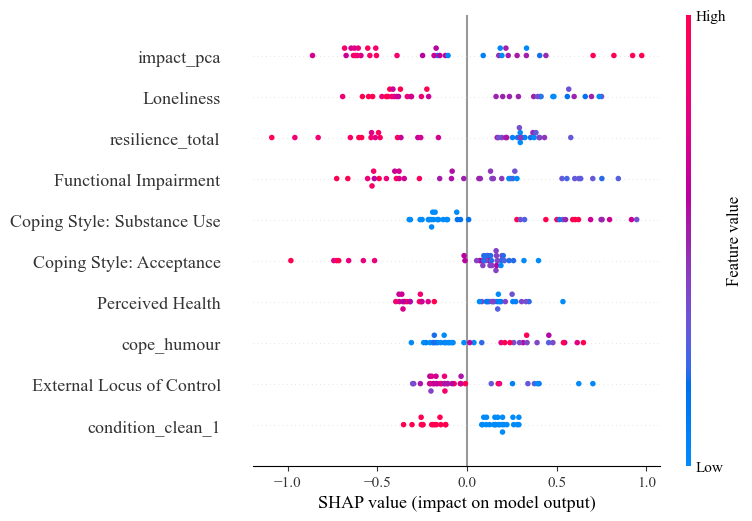

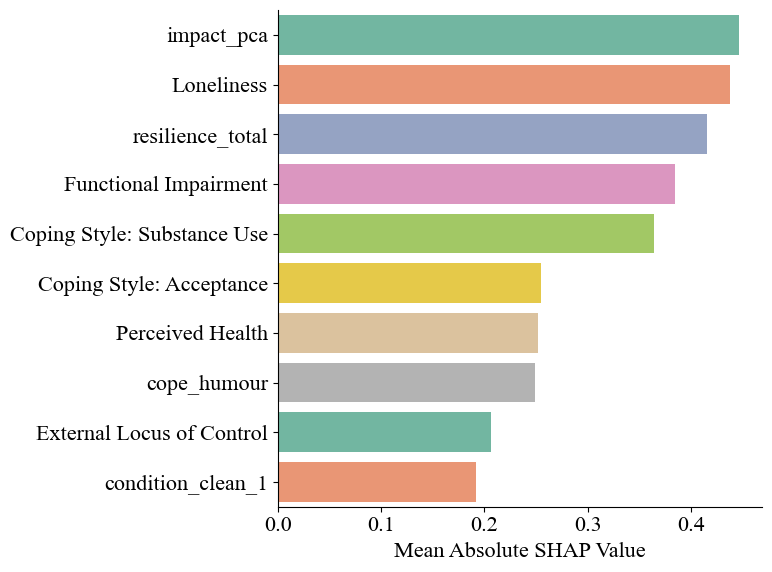

In [62]:
## SHAP Values
explainer_age_2 = shap.Explainer(final_model_age_2, X_train_scaled_age_2, feature_names=feature_names_age_2)

shap_test_age_2 = explainer_age_2(X_test_scaled_age_2)

## SHAP VALUES 
mean_abs_shap_age_2 = np.mean(np.abs(shap_test_age_2.values), axis=0)
feature_importance_age_2 = pd.DataFrame({
    "Feature": feature_names_age_2, 
    "Mean Absolute SHAP value": mean_abs_shap_age_2
}).sort_values(by="Mean Absolute SHAP value", ascending=False)

print(feature_importance_age_2.head(10))

clean_map = {
    "loc_ext": "External Locus of Control", 
    "lonely_total_new": "Loneliness",
    "perc_health_total": "Perceived Health",
    "WSAS_pre": "Functional Impairment",
    "cope_substuse": "Coping Style: Substance Use",
    "cope_acceptance": "Coping Style: Acceptance",
    "current_mh_duration_clean": "Current Mental Health Duration",
    "stresslife_total_new": "Stressful Life Events",
    "GAD7_pre": "Baseline Anxiety Symptom Severity",
    "benefits": "Benefits Recipient",
    "cope_emotsupp": "Coping Style: Emotional Support",
    "self_compassion_pca": "Self-compassion (PCA)"}

clean_names_full = [clean_map.get(col, col) for col in feature_names_age_2]

## Summary plot
shap.summary_plot(
    shap_test_age_2.values, 
    features=X_test_scaled_age_2, 
    feature_names=clean_names_full,  
    max_display=10,
    show=False)
plt.tight_layout()
plt.savefig("shap_XGage_2_summary.png", dpi=300, bbox_inches="tight")
plt.show()

top10_features = feature_importance_age_2.head(10).copy()
top10_features["clean Feature"] = top10_features["Feature"].map(clean_map).fillna(top10_features["Feature"])

## Barchart
plt.figure(figsize=(8, 6))
sns.barplot(
    data=top10_features,  
    y="clean Feature", x="Mean Absolute SHAP value", palette="Set2"
)
plt.title("")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("")
plt.tight_layout()
sns.despine()
plt.savefig("shap_XGage_2_summary2.png", dpi=300, bbox_inches="tight")
plt.show()


#### Age_3

In [63]:
## Split into train (70%), Validation (15%), and Test (15%)
train_df_age_3, rem_df_age_3 = train_test_split(df_age_3, train_size=0.7, 
                                                          stratify=df_age_3["rel_recovery"], random_state=randomstate)

val_df_age_3, test_df_age_3 = train_test_split(rem_df_age_3, train_size=0.5, 
                                                         stratify=rem_df_age_3["rel_recovery"], random_state=randomstate)

In [64]:
## One-hot encode categorical variables

df_age_3_encoded = pd.get_dummies(df_age_3, columns=["gender", "mh_onset_cat", "ethnicity_3", "condition_clean",
                                         "employment_status_3"], drop_first=True)

train_df_age_3_encoded = pd.get_dummies(train_df_age_3, columns=["gender", "mh_onset_cat", "ethnicity_3", "condition_clean",
                                         "employment_status_3"], drop_first=True)

val_df_age_3_encoded = pd.get_dummies(val_df_age_3, columns=["gender", "mh_onset_cat", "ethnicity_3", "condition_clean",
                                         "employment_status_3"], drop_first=True)

test_df_age_3_encoded = pd.get_dummies(test_df_age_3, columns=["gender", "mh_onset_cat", "ethnicity_3", "condition_clean",
                                         "employment_status_3"], drop_first=True)


In [65]:
all_features_age = [1,2,3,4,5,6,7,8,9,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,
                    45,46,47,48,50,51,52,53,54,44]

df_age_3_encoded_1 = df_age_3_encoded.iloc[:, all_features_age].copy()
train_df_age_3_encoded_1 = train_df_age_3_encoded.iloc[:, all_features_age].copy()
val_df_age_3_encoded_1 = val_df_age_3_encoded.iloc[:, all_features_age].copy()
test_df_age_3_encoded_1 = test_df_age_3_encoded.iloc[:, all_features_age].copy()

data_df_age_3 = np.array(df_age_3_encoded_1)
train_df_age_3 = np.array(train_df_age_3_encoded_1)
val_df_age_3 = np.array(val_df_age_3_encoded_1)
test_df_age_3 = np.array(test_df_age_3_encoded_1)

In [66]:
## All Features
feat_col_full = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,
                32,33,34,35,36,37,38,39,40,41]

rel_recovery = 42
feature_names_age_3 = test_df_age_3_encoded_1.columns[feat_col_full]

X_train_age_3 = train_df_age_3[:, feat_col_full]
y_train_age_3 = train_df_age_3[:, rel_recovery].astype(int)

X_val_age_3 = val_df_age_3[:, feat_col_full]
y_val_age_3 = val_df_age_3[:, rel_recovery].astype(int)

X_test_age_3 = test_df_age_3[:, feat_col_full]
y_test_age_3 = test_df_age_3[:, rel_recovery].astype(int)

print(f"Train: {X_train_age_3.shape[0]}, Val: {X_val_age_3.shape[0]}, Test: {X_test_age_3.shape[0]}")
print(f"Train: {X_train_age_3.shape[1]}, Val: {X_val_age_3.shape[1]}, Test: {X_test_age_3.shape[1]}")


Train: 211, Val: 45, Test: 46
Train: 42, Val: 42, Test: 42


In [67]:
## Scale Features
scaler_age_3 = StandardScaler()
X_train_scaled_age_3 = scaler_age_3.fit_transform(X_train_age_3)
X_val_scaled_age_3 = scaler_age_3.transform(X_val_age_3)
X_test_scaled_age_3 = scaler_age_3.transform(X_test_age_3)

## GridSearch
param_grid_age_3 = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7]}

base_model_age_3 = XGBClassifier(random_state=randomstate)
grid_search_age_3 = GridSearchCV(base_model_age_3, param_grid_age_3, cv=5, scoring="roc_auc", n_jobs=-1)
grid_search_age_3.fit(X_train_scaled_age_3, y_train_age_3)

best_params_age_3 = grid_search_age_3.best_params_
print(f"\nBest Params: {best_params_age_3}")

## 10-Fold CV 
skf_age_3 = StratifiedKFold(n_splits=10, shuffle=True, random_state=randomstate)

f1_scores_age_3 = []
rocauc_scores_age_3 = []
logloss_scores_age_3 = []
all_preds_age_3 = []
all_true_age_3 = []

for fold, (train_idx_age_3, test_idx_age_3) in enumerate(skf_age_3.split(X_train_scaled_age_3, y_train_age_3), 1):
    X_fold_train_age_3 = X_train_scaled_age_3[train_idx_age_3]
    X_fold_test_age_3 = X_train_scaled_age_3[test_idx_age_3]
    y_fold_train_age_3 = y_train_age_3[train_idx_age_3]
    y_fold_test_age_3 = y_train_age_3[test_idx_age_3]

    model_age_3 = XGBClassifier(**best_params_age_3,random_state=randomstate,use_label_encoder=False)
    model_age_3.fit(X_fold_train_age_3, y_fold_train_age_3)

    y_pred_age_3 = model_age_3.predict(X_fold_test_age_3)
    y_proba_age_3 = model_age_3.predict_proba(X_fold_test_age_3)[:, 1]  

    f1_age_3 = f1_score(y_fold_test_age_3, y_pred_age_3)
    f1_scores_age_3.append(f1_age_3)

    rocauc_age_3 = roc_auc_score(y_fold_test_age_3, y_proba_age_3)
    rocauc_scores_age_3.append(rocauc_age_3)

    logloss_age_3 = log_loss(y_fold_test_age_3, y_proba_age_3)
    logloss_scores_age_3.append(logloss_age_3)

    all_preds_age_3.extend(y_pred_age_3)
    all_true_age_3.extend(y_fold_test_age_3)

    print(f"Fold {fold} F1 Score: {f1_age_3:.4f}, ROC AUC: {rocauc_age_3:.4f}, Log Loss: {logloss_age_3:.4f}")

print(f"\nAverage CV F1 Score: {np.mean(f1_scores_age_3):.4f}")
print(f"Average CV ROC AUC: {np.mean(rocauc_scores_age_3):.4f}")
print(f"Average CV Log Loss: {np.mean(logloss_scores_age_3):.4f}")
print("Overall Precision:", precision_score(all_true_age_3, all_preds_age_3))
print("Overall Recall:", recall_score(all_true_age_3, all_preds_age_3))

## Final Model on training set
final_model_age_3 = XGBClassifier(**best_params_age_3, random_state=randomstate, use_label_encoder=False)
final_model_age_3.fit(X_train_scaled_age_3, y_train_age_3)


## Validation set
y_val_pred_age_3 = final_model_age_3.predict(X_val_scaled_age_3)
y_val_proba_age_3 = final_model_age_3.predict_proba(X_val_scaled_age_3)[:, 1]

val_roc_auc_age_3 = roc_auc_score(y_val_age_3, y_val_proba_age_3)
val_prec_age_3 = precision_score(y_val_age_3, y_val_pred_age_3)
val_rec_age_3 = recall_score(y_val_age_3, y_val_pred_age_3)
val_f1_age_3 = f1_score(y_val_age_3, y_val_pred_age_3)
val_acc_age_3 = accuracy_score(y_val_age_3, y_val_pred_age_3)
val_logloss_age_3 = log_loss(y_val_age_3, y_val_proba_age_3)
val_confmat_age_3 = confusion_matrix(y_val_age_3, y_val_pred_age_3)

print("\nValidation Metrics:")
print(f"Accuracy:     {val_acc_age_3:.4f}")
print(f"Precision:    {val_prec_age_3:.4f}")
print(f"Recall:       {val_rec_age_3:.4f}")
print(f"F1 Score:     {val_f1_age_3:.4f}")
print(f"ROC AUC:      {val_roc_auc_age_3:.4f}")
print(f"Log Loss:     {val_logloss_age_3:.4f}")
print("Confusion Matrix:\n", val_confmat_age_3)
print("\nClassification Report:\n", classification_report(y_val_age_3, y_val_pred_age_3))

## Evaluate on Test set
y_test_pred_age_3 = final_model_age_3.predict(X_test_scaled_age_3)
y_test_proba5_age_3 = final_model_age_3.predict_proba(X_test_scaled_age_3)[:, 1]

test_roc_auc_age_3 = roc_auc_score(y_test_age_3, y_test_proba5_age_3)
test_prec_age_3 = precision_score(y_test_age_3, y_test_pred_age_3)
test_rec_age_3 = recall_score(y_test_age_3, y_test_pred_age_3)
test_f1_age_3 = f1_score(y_test_age_3, y_test_pred_age_3)
test_acc_age_3 = accuracy_score(y_test_age_3, y_test_pred_age_3)
test_logloss_age_3 = log_loss(y_test_age_3, y_test_proba5_age_3)
test_confmat_age_3 = confusion_matrix(y_test_age_3, y_test_pred_age_3)

print("\nTest Metrics:")
print(f"Accuracy:     {test_acc_age_3:.4f}")
print(f"Precision:    {test_prec_age_3:.4f}")
print(f"Recall:       {test_rec_age_3:.4f}")
print(f"F1 Score:     {test_f1_age_3:.4f}")
print(f"ROC AUC:      {test_roc_auc_age_3:.4f}")
print(f"Log Loss:     {test_logloss_age_3:.4f}")
print("Confusion Matrix:\n", test_confmat_age_3)

results_age_3 = {
    "Set": ["Validation_XGFull", "Test_XGFull"],
    "Accuracy": [val_acc_age_3, test_acc_age_3],
    "Precision": [val_prec_age_3, test_prec_age_3],
    "Recall": [val_rec_age_3, test_rec_age_3],
    "F1 Score": [val_f1_age_3, test_f1_age_3],
    "ROC AUC": [val_roc_auc_age_3, test_roc_auc_age_3],
    "Log Loss": [val_logloss_age_3, test_logloss_age_3]}

## Save validation and test metrics and test set predictions/true values
results_df_XGage_3 = pd.DataFrame(results_age_3)
print(results_df_XGage_3)



Best Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}
Fold 1 F1 Score: 0.7692, ROC AUC: 0.7500, Log Loss: 0.5634
Fold 2 F1 Score: 0.6400, ROC AUC: 0.6636, Log Loss: 0.7206
Fold 3 F1 Score: 0.7500, ROC AUC: 0.6944, Log Loss: 0.6402
Fold 4 F1 Score: 0.5217, ROC AUC: 0.5370, Log Loss: 0.7774
Fold 5 F1 Score: 0.8182, ROC AUC: 0.8241, Log Loss: 0.5280
Fold 6 F1 Score: 0.7857, ROC AUC: 0.8056, Log Loss: 0.5853
Fold 7 F1 Score: 0.3810, ROC AUC: 0.4907, Log Loss: 0.7365
Fold 8 F1 Score: 0.5385, ROC AUC: 0.4815, Log Loss: 0.7550
Fold 9 F1 Score: 0.6897, ROC AUC: 0.5370, Log Loss: 0.8102
Fold 10 F1 Score: 0.6667, ROC AUC: 0.6204, Log Loss: 0.6934

Average CV F1 Score: 0.6561
Average CV ROC AUC: 0.6404
Average CV Log Loss: 0.6810
Overall Precision: 0.6287878787878788
Overall Recall: 0.6974789915966386

Validation Metrics:
Accuracy:     0.6000
Precision:    0.6522
Recall:       0.6000
F1 Score:     0.6250
ROC AUC:      0.6240
Log Loss:     0.6953
Confusion Matrix:
 [[12  8]
 [

                Feature  Mean Absolute SHAP value
8      lonely_total_new                  0.516784
7              WSAS_pre                  0.254662
36           impact_pca                  0.192022
18         pers_openexp                  0.173696
17        pers_emotstab                  0.136266
35  self_compassion_pca                  0.129505
11    perc_health_total                  0.109848
28        cope_planning                  0.085412
9      resilience_total                  0.070264
6              GAD7_pre                  0.056032


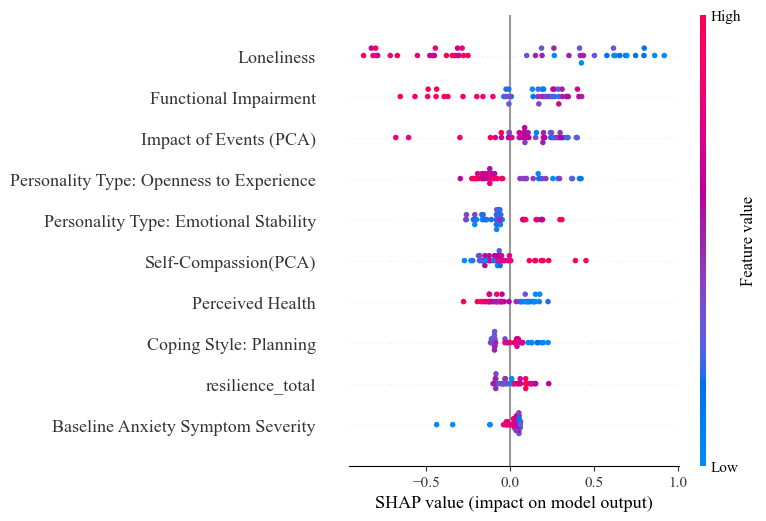

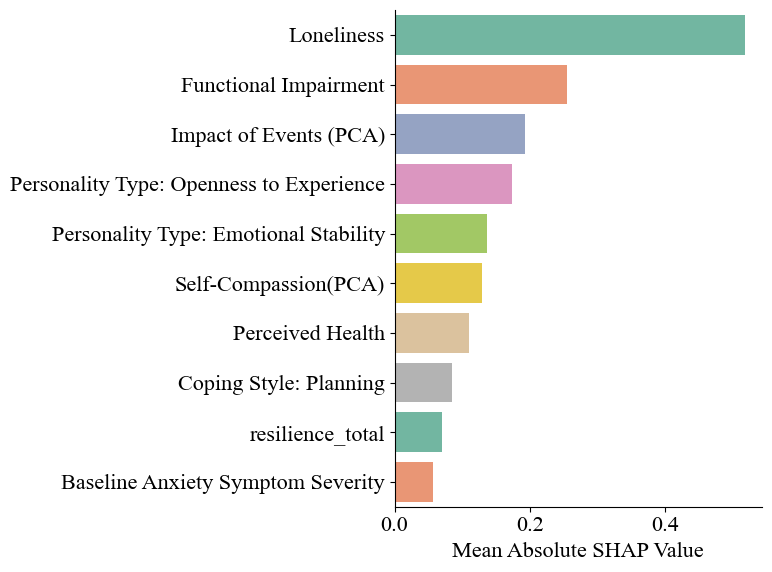

In [68]:
## SHAP Values
explainer_age_3 = shap.Explainer(final_model_age_3, X_train_scaled_age_3, feature_names=feature_names_age_3)

shap_test_age_3 = explainer_age_3(X_test_scaled_age_3)

## SHAP VALUES (Feature Importance Table)
mean_abs_shap_age_3 = np.mean(np.abs(shap_test_age_3.values), axis=0)
feature_importance_age_3 = pd.DataFrame({
    "Feature": feature_names_age_3, 
    "Mean Absolute SHAP value": mean_abs_shap_age_3
}).sort_values(by="Mean Absolute SHAP value", ascending=False)

print(feature_importance_age_3.head(10))

clean_map = {
    "lonely_total_new": "Loneliness",
    "pers_emotstab": "Personality Type: Emotional Stability",
    "pers_openexp": "Personality Type: Openness to Experience",
    "impact_pca": "Impact of Events (PCA)",
    "WSAS_pre": "Functional Impairment", 
    "cope_substuse": "Coping Style: Substance Use",
    "self_compassion_pca": "Self-Compassion(PCA)",
    "stresslife_total_new": "Stressful Life Events",
    "perc_health_total": "Perceived Health",
    "cope_denial": "Coping Style: Denial",
    "GAD7_pre": "Baseline Anxiety Symptom Severity",
    "cope_religion": "Coping Style: Religion",  
    "cope_planning": "Coping Style: Planning"}


clean_names_full = [clean_map.get(col, col) for col in feature_names_age_3]

## Summary plot
shap.summary_plot(
    shap_test_age_3.values, 
    features=X_test_scaled_age_3, 
    feature_names=clean_names_full,  
    max_display=10,
    show=False)
plt.tight_layout()
plt.savefig("shap_XGage_3_summary.png", dpi=300, bbox_inches="tight")
plt.show()

top10_features = feature_importance_age_3.head(10).copy()
top10_features["clean Feature"] = top10_features["Feature"].map(clean_map).fillna(top10_features["Feature"])

## Barchart
plt.figure(figsize=(8, 6))
sns.barplot(
    data=top10_features,  
    y="clean Feature", x="Mean Absolute SHAP value", palette="Set2")
plt.title("")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("")
plt.tight_layout()
sns.despine()
plt.savefig("shap_XGage_3_summary2.png", dpi=300, bbox_inches="tight")
plt.show()

